#### Imports, configuration and output folders

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    """
    Search the current directory and its parents for the project root.

    The project root must contain both:
    - config/__init__.py
    - src/__init__.py
    """
    start_path = (start or Path.cwd()).resolve()

    for candidate in (start_path, *start_path.parents):
        config_init = candidate / "config" / "__init__.py"
        src_init = candidate / "src" / "__init__.py"

        if config_init.is_file() and src_init.is_file():
            return candidate

    raise FileNotFoundError(
        "Project root could not be found. "
        "Confirm that config/__init__.py and src/__init__.py exist."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Project root added to sys.path: {str(PROJECT_ROOT) in sys.path}")

Project root: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los
Project root added to sys.path: True


In [7]:
from __future__ import annotations

import inspect
import json
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.model_selection import train_test_split

from config.paths import (
    COHORT_DIR,
    FIGURE_DIR,
    OUTPUT_DIR,
    REDUCED_DATA_DIR,
)

In [6]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COLUMN = "prolonged_icu_los"


MODELING_COHORT_FILE = (
    REDUCED_DATA_DIR
    / "modeling_cohort_v001.csv"
)

FEATURE_MANIFEST_FILE = (
    COHORT_DIR
    / "qc"
    / "modeling_feature_manifest_v001.csv"
)

HISTORY_MANIFEST_FILE = (
    COHORT_DIR
    / "qc"
    / "past_history_feature_manifest.csv"
)


MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"
MODELING_FIGURE_DIR = (
    FIGURE_DIR / "modeling"
)
SPLIT_DIR = OUTPUT_DIR / "splits"


for directory in (
    MODEL_DIR,
    METRIC_DIR,
    MODELING_FIGURE_DIR,
    SPLIT_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

#### Recording the software environment

In [7]:
print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.10.10
Platform: Windows-10-10.0.19045-SP0
pandas: 2.3.3
NumPy: 2.2.6
scikit-learn: 1.7.2


#### Loading and validating the modelling cohort

In [8]:
modeling_cohort = pd.read_csv(
    MODELING_COHORT_FILE,
    low_memory=False,
)

feature_manifest = pd.read_csv(
    FEATURE_MANIFEST_FILE,
    low_memory=False,
)

history_manifest = pd.read_csv(
    HISTORY_MANIFEST_FILE,
    low_memory=False,
)

#### Validating its structure

In [9]:
required_columns = {
    "patientunitstayid",
    TARGET_COLUMN,
}

missing_required = required_columns.difference(
    modeling_cohort.columns
)

if missing_required:
    raise KeyError(
        "Missing required modelling columns: "
        + ", ".join(sorted(missing_required))
    )


modeling_cohort["patientunitstayid"] = (
    pd.to_numeric(
        modeling_cohort["patientunitstayid"],
        errors="raise",
    )
    .astype("int64")
)

modeling_cohort[TARGET_COLUMN] = (
    pd.to_numeric(
        modeling_cohort[TARGET_COLUMN],
        errors="raise",
    )
    .astype("int8")
)


assert len(modeling_cohort) == 1_389

assert modeling_cohort[
    "patientunitstayid"
].is_unique

assert set(
    modeling_cohort[TARGET_COLUMN].unique()
).issubset({0, 1})

assert int(
    modeling_cohort[TARGET_COLUMN].sum()
) == 286


print(
    "Rows:",
    f"{len(modeling_cohort):,}",
)

print(
    "Columns:",
    f"{modeling_cohort.shape[1]:,}",
)

print(
    "Positive cases:",
    (
        f"{modeling_cohort[TARGET_COLUMN].sum():,} "
        f"({100 * modeling_cohort[TARGET_COLUMN].mean():.2f}%)"
    ),
)

Rows: 1,389
Columns: 278
Positive cases: 286 (20.59%)


### Normalizing infinite values and age

#### Converting accidental infinite derived values to missing

In [10]:
modeling_cohort = modeling_cohort.replace(
    [np.inf, -np.inf],
    np.nan,
)

#### Handling eICU’s possible >89 age representation

In [11]:
possible_age_columns = [
    column
    for column in modeling_cohort.columns
    if column.lower() in {
        "age",
        "patient_age",
        "age_numeric",
    }
]


for age_column in possible_age_columns:
    age_text = (
        modeling_cohort[age_column]
        .astype("string")
        .str.strip()
        .replace(
            {
                "> 89": "90",
                ">89": "90",
            }
        )
    )

    converted_age = pd.to_numeric(
        age_text,
        errors="coerce",
    )

    if converted_age.notna().sum() > 0:
        modeling_cohort[age_column] = (
            converted_age
        )

        print(
            f"Converted {age_column} "
            "to numeric."
        )

Converted age to numeric.


#### Reconstructing the eligible predictor pool

In [12]:
allowed_manifest_roles = {
    "candidate_predictor",
    "availability_or_care_process",
}


manifest_predictor_pool = (
    feature_manifest.loc[
        feature_manifest["role"].isin(
            allowed_manifest_roles
        ),
        "feature",
    ]
    .dropna()
    .astype(str)
    .tolist()
)


manifest_predictor_pool = [
    column
    for column in manifest_predictor_pool
    if column in modeling_cohort.columns
]

#### Applying a second independent leakage audit

In [13]:
FORBIDDEN_MODEL_PATTERNS = [
    "patientunitstayid",
    "patienthealthsystemstayid",
    "uniquepid",
    "hospitalid",
    "wardid",

    "unitdischarge",
    "hospitaldischarge",

    "actualicu",
    "actualhospital",

    "predictediculos",
    "predicted_icu_los",

    "mortality",
    "death",
    "died",

    "length_of_stay",
    "icu_los",
    "los_days",

    "prolonged_icu_los",
]

In [14]:
def contains_forbidden_pattern(
    column: str,
) -> bool:
    column_lower = column.lower()

    return any(
        forbidden in column_lower
        for forbidden
        in FORBIDDEN_MODEL_PATTERNS
    )


safe_predictor_pool = [
    column
    for column in manifest_predictor_pool
    if not contains_forbidden_pattern(
        column
    )
]


removed_by_second_audit = sorted(
    set(manifest_predictor_pool)
    - set(safe_predictor_pool)
)


print(
    "Manifest predictor pool:",
    len(manifest_predictor_pool),
)

print(
    "Removed by independent leakage audit:",
    len(removed_by_second_audit),
)

print(
    "Safe predictor pool:",
    len(safe_predictor_pool),
)

Manifest predictor pool: 256
Removed by independent leakage audit: 2
Safe predictor pool: 254


#### Displaying the removed fields

In [15]:
pd.DataFrame(
    {
        "removed_feature": (
            removed_by_second_audit
        )
    }
)

,removed_feature
0,hospital_mortality
1,icu_mortality


### Defining Model A: clinical baseline without APACHE
#### Cohort and demographic variables

In [16]:
cohort_demographic_columns = (
    feature_manifest.loc[
        (
            feature_manifest[
                "source_block"
            ].eq(
                "cohort_or_demographic"
            )
        )
        & (
            feature_manifest[
                "role"
            ].eq(
                "candidate_predictor"
            )
        ),
        "feature",
    ]
    .dropna()
    .astype(str)
    .tolist()
)


cohort_demographic_columns = [
    column
    for column
    in cohort_demographic_columns
    if (
        column in safe_predictor_pool
        and not contains_forbidden_pattern(
            column
        )
    )
]

#### Core laboratory variables
Using the stronger-coverage laboratory group for the first clinical model

In [17]:
CORE_LABORATORIES = [
    "creatinine",
    "potassium",
    "sodium",
    "bun",
    "chloride",
    "glucose",
    "hematocrit",
    "calcium_total",
    "hemoglobin",
    "wbc",
    "platelets",
    "bicarbonate",
    "anion_gap",
]

PRIMARY_LAB_STATISTICS = [
    "first",
    "median",
    "min",
    "max",
]

In [18]:
core_lab_columns = [
    f"lab_{laboratory}_{statistic}"
    for laboratory in CORE_LABORATORIES
    for statistic in PRIMARY_LAB_STATISTICS
]


missing_core_lab_columns = sorted(
    set(core_lab_columns)
    - set(modeling_cohort.columns)
)

if missing_core_lab_columns:
    print(
        "Warning: expected laboratory "
        "features not found:"
    )

    print(
        "\n".join(
            missing_core_lab_columns
        )
    )


core_lab_columns = [
    column
    for column in core_lab_columns
    if column in safe_predictor_pool
]

#### Primary vital-sign variables

In [22]:
primary_vital_columns = [
    column
    for column in safe_predictor_pool
    if (
        column.startswith(
            "vital_periodic_"
        )
        or column.startswith(
            "vital_aperiodic_"
        )
    )
    and not column.endswith(
        "_available"
    )
    and "measurement_count" not in column
]

#### Primary past-history variables

In [24]:
history_primary_mask = (
    history_manifest[
        "primary_model_candidate"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(
        {
            "true",
            "1",
            "yes",
        }
    )
)


primary_history_columns = (
    history_manifest.loc[
        history_primary_mask,
        "feature",
    ]
    .dropna()
    .astype(str)
    .tolist()
)


primary_history_columns = [
    column
    for column in primary_history_columns
    if column in safe_predictor_pool
]

#### Assemble Model A

In [25]:
MODEL_A_FEATURES = sorted(
    set(
        cohort_demographic_columns
        + core_lab_columns
        + primary_vital_columns
        + primary_history_columns
    )
)

In [26]:
print(
    "Model A cohort/demographic:",
    len(cohort_demographic_columns),
)

print(
    "Model A laboratory:",
    len(core_lab_columns),
)

print(
    "Model A vital signs:",
    len(primary_vital_columns),
)

print(
    "Model A past history:",
    len(primary_history_columns),
)

print(
    "Model A total:",
    len(MODEL_A_FEATURES),
)

Model A cohort/demographic: 16
Model A laboratory: 52
Model A vital signs: 35
Model A past history: 15
Model A total: 118


### Defining Model B: clinical features plus APACHE
#### APACHE prediction-variable block

In [27]:
apv_columns = [
    column
    for column in safe_predictor_pool
    if column.startswith("apv_")
]

#### Excluding availability-only fields from the primary APACHE model

In [28]:
apv_columns = [
    column
    for column in apv_columns
    if not column.endswith(
        (
            "_missing",
            "_available",
        )
    )
]

#### Selected APS physiology

In [29]:
APS_CORE_FEATURE_NAMES = [
    "intubated",
    "ventilated",
    "dialysis",
    "gcs_total",
    "temperature",
    "respiratory_rate",
    "heart_rate",
    "mean_arterial_pressure",
    "glucose",
    "sodium",
    "creatinine",
    "bun",
    "hematocrit",
    "wbc",
]

In [30]:
aps_core_columns = [
    f"aps_{feature}"
    for feature in APS_CORE_FEATURE_NAMES
]


missing_aps_columns = sorted(
    set(aps_core_columns)
    - set(modeling_cohort.columns)
)

if missing_aps_columns:
    print(
        "Warning: expected APS features "
        "not found:"
    )

    print(
        "\n".join(
            missing_aps_columns
        )
    )


aps_core_columns = [
    column
    for column in aps_core_columns
    if column in safe_predictor_pool
]

#### APACHE severity scores

In [31]:
apr_severity_columns = [
    column
    for column in modeling_cohort.columns
    if column.lower() in {
        "apr_acutephysiologyscore",
        "apr_apachescore",
    }
]

#### Verifying that no prediction field entered

In [32]:
assert not any(
    "predicted" in column.lower()
    for column in apr_severity_columns
)

#### Assembling Model B

In [33]:
MODEL_B_FEATURES = sorted(
    set(
        MODEL_A_FEATURES
        + apv_columns
        + aps_core_columns
        + apr_severity_columns
    )
)

In [34]:
print(
    "Additional APV variables:",
    len(apv_columns),
)

print(
    "Additional APS variables:",
    len(aps_core_columns),
)

print(
    "APACHE severity scores:",
    len(apr_severity_columns),
)

print(
    "Model B total:",
    len(MODEL_B_FEATURES),
)

Additional APV variables: 18
Additional APS variables: 14
APACHE severity scores: 2
Model B total: 152


#### Final feature-set leakage test

In [35]:
def audit_feature_set(
    feature_set: list[str],
    feature_set_name: str,
) -> pd.DataFrame:
    duplicated_features = sorted(
        {
            feature
            for feature in feature_set
            if feature_set.count(feature) > 1
        }
    )

    missing_features = sorted(
        set(feature_set)
        - set(modeling_cohort.columns)
    )

    forbidden_features = sorted(
        feature
        for feature in feature_set
        if contains_forbidden_pattern(
            feature
        )
    )

    audit = pd.DataFrame(
        {
            "feature_set": [
                feature_set_name
            ],
            "number_of_features": [
                len(feature_set)
            ],
            "duplicate_features": [
                len(duplicated_features)
            ],
            "missing_features": [
                len(missing_features)
            ],
            "forbidden_features": [
                len(forbidden_features)
            ],
        }
    )

    if duplicated_features:
        raise ValueError(
            f"{feature_set_name} contains "
            f"duplicate features: "
            f"{duplicated_features}"
        )

    if missing_features:
        raise KeyError(
            f"{feature_set_name} contains "
            f"missing features: "
            f"{missing_features}"
        )

    if forbidden_features:
        raise ValueError(
            f"{feature_set_name} contains "
            f"forbidden features: "
            f"{forbidden_features}"
        )

    return audit

In [36]:
feature_set_audit = pd.concat(
    [
        audit_feature_set(
            MODEL_A_FEATURES,
            "Model A: clinical baseline",
        ),
        audit_feature_set(
            MODEL_B_FEATURES,
            "Model B: clinical + APACHE",
        ),
    ],
    ignore_index=True,
)


display(feature_set_audit)

,feature_set,number_of_features,duplicate_features,missing_features,forbidden_features
0,Model A: clinical baseline,118,0,0,0
1,Model B: clinical + APACHE,152,0,0,0


### Identifying numeric and categorical features

In [37]:
FORCED_CATEGORICAL_HINTS = [
    "gender",
    "ethnicity",
    "admitsource",
    "admit_source",
    "unittype",
    "unit_type",
    "unitstaytype",
    "unit_stay_type",
    "admitdiagnosis",
    "admit_diagnosis",
]

In [38]:
def identify_feature_types(
    dataframe: pd.DataFrame,
    feature_columns: list[str],
) -> tuple[list[str], list[str]]:
    categorical_columns = []

    for column in feature_columns:
        is_text_dtype = (
            pd.api.types.is_object_dtype(
                dataframe[column]
            )
            or pd.api.types.is_string_dtype(
                dataframe[column]
            )
            or isinstance(
                dataframe[column].dtype,
                pd.CategoricalDtype,
            )
        )

        categorical_name_hint = any(
            hint in column.lower()
            for hint
            in FORCED_CATEGORICAL_HINTS
        )

        if (
            is_text_dtype
            or categorical_name_hint
        ):
            categorical_columns.append(
                column
            )

    numeric_columns = [
        column
        for column in feature_columns
        if column not in categorical_columns
    ]

    return (
        sorted(numeric_columns),
        sorted(categorical_columns),
    )

In [39]:
MODEL_A_NUMERIC, MODEL_A_CATEGORICAL = (
    identify_feature_types(
        modeling_cohort,
        MODEL_A_FEATURES,
    )
)

MODEL_B_NUMERIC, MODEL_B_CATEGORICAL = (
    identify_feature_types(
        modeling_cohort,
        MODEL_B_FEATURES,
    )
)

In [40]:
print(
    "Model A numeric:",
    len(MODEL_A_NUMERIC),
)

print(
    "Model A categorical:",
    len(MODEL_A_CATEGORICAL),
)

print(
    "Model B numeric:",
    len(MODEL_B_NUMERIC),
)

print(
    "Model B categorical:",
    len(MODEL_B_CATEGORICAL),
)

Model A numeric: 109
Model A categorical: 9
Model B numeric: 141
Model B categorical: 11


#### Displaying categorical fields for manual verification

In [41]:
pd.DataFrame(
    {
        "Model A categorical": pd.Series(
            MODEL_A_CATEGORICAL
        ),
        "Model B categorical": pd.Series(
            MODEL_B_CATEGORICAL
        ),
    }
)

,Model A categorical,Model B categorical
0,apacheadmissiondx,apacheadmissiondx
1,ethnicity,apv_admitdiagnosis
2,gender,apv_admitsource
3,hospitaladmitsource,ethnicity
4,hospitaladmittime24,gender
5,unitadmitsource,hospitaladmitsource
6,unitadmittime24,hospitaladmittime24
7,unitstaytype,unitadmitsource
8,unittype,unitadmittime24
9,NaN,unitstaytype


### Creating the sealed development/test split

In [42]:
row_indices = np.arange(
    len(modeling_cohort)
)

target = modeling_cohort[
    TARGET_COLUMN
].copy()

In [43]:
development_indices, test_indices = (
    train_test_split(
        row_indices,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=target,
    )
)

#### Creating development and test data

In [44]:
development_data = (
    modeling_cohort
    .iloc[development_indices]
    .copy()
)

test_data = (
    modeling_cohort
    .iloc[test_indices]
    .copy()
)

#### Sorting only for reproducibility

In [45]:
development_data = (
    development_data
    .sort_values(
        "patientunitstayid"
    )
    .reset_index(drop=True)
)

test_data = (
    test_data
    .sort_values(
        "patientunitstayid"
    )
    .reset_index(drop=True)
)

### Validating the sealed split

In [46]:
development_ids = set(
    development_data[
        "patientunitstayid"
    ]
)

test_ids = set(
    test_data[
        "patientunitstayid"
    ]
)


assert development_ids.isdisjoint(
    test_ids
)

assert (
    len(development_data)
    + len(test_data)
    == len(modeling_cohort)
)

assert development_ids.union(
    test_ids
) == set(
    modeling_cohort[
        "patientunitstayid"
    ]
)

#### Creating the outcome summary

In [47]:
split_summary = pd.DataFrame(
    {
        "split": [
            "development",
            "test",
            "total",
        ],
        "patient_count": [
            len(development_data),
            len(test_data),
            len(modeling_cohort),
        ],
        "prolonged_count": [
            int(
                development_data[
                    TARGET_COLUMN
                ].sum()
            ),
            int(
                test_data[
                    TARGET_COLUMN
                ].sum()
            ),
            int(
                modeling_cohort[
                    TARGET_COLUMN
                ].sum()
            ),
        ],
    }
)


split_summary["non_prolonged_count"] = (
    split_summary["patient_count"]
    - split_summary["prolonged_count"]
)

split_summary["prolonged_percent"] = (
    100
    * split_summary["prolonged_count"]
    / split_summary["patient_count"]
)


display(split_summary)

,split,patient_count,prolonged_count,non_prolonged_count,prolonged_percent
0,development,1111,229,882,20.612061
1,test,278,57,221,20.503597
2,total,1389,286,1103,20.590353


### Creating the private split manifest

In [48]:
split_manifest = pd.concat(
    [
        development_data[
            [
                "patientunitstayid",
                TARGET_COLUMN,
            ]
        ].assign(
            split="development"
        ),

        test_data[
            [
                "patientunitstayid",
                TARGET_COLUMN,
            ]
        ].assign(
            split="test"
        ),
    ],
    ignore_index=True,
)

In [49]:
assert len(split_manifest) == 1_389

assert split_manifest[
    "patientunitstayid"
].is_unique

In [50]:
PRIVATE_SPLIT_FILE = (
    SPLIT_DIR
    / "train_test_split_manifest_v001.csv"
)

SAFE_SPLIT_SUMMARY_FILE = (
    METRIC_DIR
    / "train_test_split_summary_v001.csv"
)


split_manifest.to_csv(
    PRIVATE_SPLIT_FILE,
    index=False,
)

split_summary.to_csv(
    SAFE_SPLIT_SUMMARY_FILE,
    index=False,
)


print(
    f"Private split manifest: "
    f"{PRIVATE_SPLIT_FILE}"
)

print(
    f"Safe split summary: "
    f"{SAFE_SPLIT_SUMMARY_FILE}"
)

Private split manifest: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\splits\train_test_split_manifest_v001.csv
Safe split summary: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\metrics\train_test_split_summary_v001.csv


### Saving the feature-set definitions

In [51]:
feature_set_definition = {
    "target": TARGET_COLUMN,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,

    "model_a": {
        "description": (
            "Clinical baseline without "
            "APACHE-derived features"
        ),
        "features": MODEL_A_FEATURES,
        "numeric_features": (
            MODEL_A_NUMERIC
        ),
        "categorical_features": (
            MODEL_A_CATEGORICAL
        ),
    },

    "model_b": {
        "description": (
            "Clinical baseline plus APACHE "
            "admission, physiology and "
            "severity variables"
        ),
        "features": MODEL_B_FEATURES,
        "numeric_features": (
            MODEL_B_NUMERIC
        ),
        "categorical_features": (
            MODEL_B_CATEGORICAL
        ),
    },
}

In [52]:
FEATURE_SET_FILE = (
    MODEL_DIR
    / "model_feature_sets_v001.json"
)


with FEATURE_SET_FILE.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        feature_set_definition,
        file,
        indent=2,
    )


print(
    f"Feature-set definition: "
    f"{FEATURE_SET_FILE}"
)

Feature-set definition: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\models\model_feature_sets_v001.json


### Creating the first modelling figure

In [53]:
plot_data = (
    split_summary.loc[
        split_summary["split"].isin(
            ["development", "test"]
        )
    ]
    .set_index("split")
    [
        [
            "non_prolonged_count",
            "prolonged_count",
        ]
    ]
)

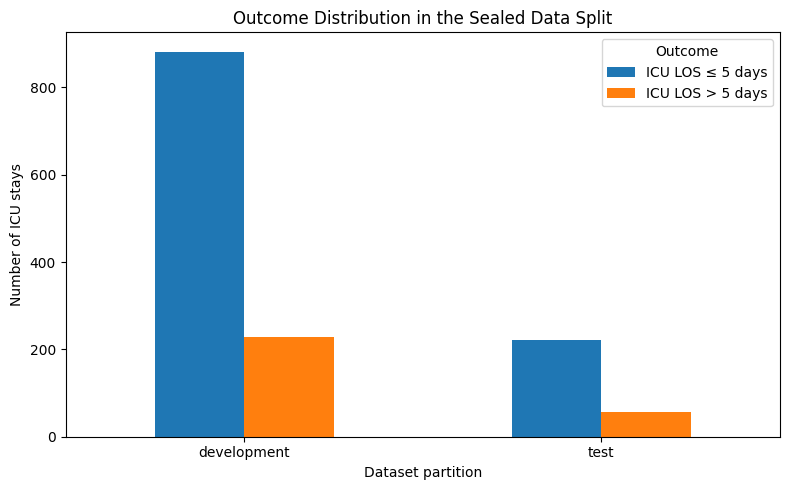

In [54]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

plot_data.plot(
    kind="bar",
    ax=ax,
)

ax.set_xlabel(
    "Dataset partition"
)

ax.set_ylabel(
    "Number of ICU stays"
)

ax.set_title(
    "Outcome Distribution in the Sealed Data Split"
)

ax.legend(
    [
        "ICU LOS ≤ 5 days",
        "ICU LOS > 5 days",
    ],
    title="Outcome",
)

ax.tick_params(
    axis="x",
    rotation=0,
)

fig.tight_layout()


SPLIT_FIGURE_FILE = (
    MODELING_FIGURE_DIR
    / "train_test_outcome_distribution.png"
)

fig.savefig(
    SPLIT_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Final Stage-1 checkpoint

In [55]:
print("MODEL STAGE 1 CHECKPOINT")
print("-" * 50)

print(
    "Development rows:",
    f"{len(development_data):,}",
)

print(
    "Development positives:",
    (
        f"{development_data[TARGET_COLUMN].sum():,} "
        f"({100 * development_data[TARGET_COLUMN].mean():.2f}%)"
    ),
)

print(
    "Test rows:",
    f"{len(test_data):,}",
)

print(
    "Test positives:",
    (
        f"{test_data[TARGET_COLUMN].sum():,} "
        f"({100 * test_data[TARGET_COLUMN].mean():.2f}%)"
    ),
)

print(
    "Patient overlap:",
    len(
        development_ids.intersection(
            test_ids
        )
    ),
)

print(
    "Model A features:",
    len(MODEL_A_FEATURES),
)

print(
    "Model B features:",
    len(MODEL_B_FEATURES),
)

print(
    "Forbidden features in Model A:",
    sum(
        contains_forbidden_pattern(column)
        for column in MODEL_A_FEATURES
    ),
)

print(
    "Forbidden features in Model B:",
    sum(
        contains_forbidden_pattern(column)
        for column in MODEL_B_FEATURES
    ),
)

MODEL STAGE 1 CHECKPOINT
--------------------------------------------------
Development rows: 1,111
Development positives: 229 (20.61%)
Test rows: 278
Test positives: 57 (20.50%)
Patient overlap: 0
Model A features: 118
Model B features: 152
Forbidden features in Model A: 0
Forbidden features in Model B: 0


### Cross-validated baseline models

#### Recording the two removed features

In [56]:
LEAKAGE_AUDIT_FILE = (
    METRIC_DIR
    / "independent_leakage_audit_removed_features.csv"
)

leakage_audit_removed = pd.DataFrame(
    {
        "removed_feature": (
            removed_by_second_audit
        )
    }
)

leakage_audit_removed.to_csv(
    LEAKAGE_AUDIT_FILE,
    index=False,
)

print("Removed by independent leakage audit:")

display(leakage_audit_removed)

assert len(removed_by_second_audit) == 2

assert all(
    contains_forbidden_pattern(feature)
    for feature in removed_by_second_audit
)

print("Independent leakage audit passed.")

Removed by independent leakage audit:


,removed_feature
0,hospital_mortality
1,icu_mortality


Independent leakage audit passed.


#### Importing modelling components

In [57]:
import inspect
import time
import warnings

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [58]:
warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning,
)

#### Preparing development-only feature matrices

In [59]:
def prepare_feature_frame(
    dataframe: pd.DataFrame,
    feature_columns: list[str],
    categorical_columns: list[str],
) -> pd.DataFrame:
    """
    Select predictor columns and normalize categorical representation.

    This transformation does not learn any statistics from the data.
    """

    feature_frame = dataframe.loc[
        :,
        feature_columns,
    ].copy()

    for column in categorical_columns:
        feature_frame[column] = (
            feature_frame[column]
            .map(
                lambda value: (
                    str(value)
                    if pd.notna(value)
                    else np.nan
                )
            )
            .astype("object")
        )

    return feature_frame

#### Preparing Model A

In [60]:
X_DEVELOPMENT_A = prepare_feature_frame(
    dataframe=development_data,
    feature_columns=MODEL_A_FEATURES,
    categorical_columns=MODEL_A_CATEGORICAL,
)

Y_DEVELOPMENT = (
    development_data[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

#### Preparing Model B

In [61]:
X_DEVELOPMENT_B = prepare_feature_frame(
    dataframe=development_data,
    feature_columns=MODEL_B_FEATURES,
    categorical_columns=MODEL_B_CATEGORICAL,
)

#### Validation

In [62]:
assert len(X_DEVELOPMENT_A) == 1_111
assert len(X_DEVELOPMENT_B) == 1_111
assert len(Y_DEVELOPMENT) == 1_111

assert X_DEVELOPMENT_A.shape[1] == 118
assert X_DEVELOPMENT_B.shape[1] == 152

assert int(Y_DEVELOPMENT.sum()) == 229

print("Development feature matrices created successfully.")

Development feature matrices created successfully.


### Removing only completely unusable development columns

In [63]:
def identify_all_missing_columns(
    dataframe: pd.DataFrame,
) -> list[str]:
    return [
        column
        for column in dataframe.columns
        if dataframe[column].isna().all()
    ]

In [64]:
MODEL_A_ALL_MISSING = (
    identify_all_missing_columns(
        X_DEVELOPMENT_A
    )
)

MODEL_B_ALL_MISSING = (
    identify_all_missing_columns(
        X_DEVELOPMENT_B
    )
)


print(
    "Model A all-missing development columns:",
    len(MODEL_A_ALL_MISSING),
)

print(
    "Model B all-missing development columns:",
    len(MODEL_B_ALL_MISSING),
)

print("\nModel A:")
print(MODEL_A_ALL_MISSING)

print("\nModel B:")
print(MODEL_B_ALL_MISSING)

Model A all-missing development columns: 0
Model B all-missing development columns: 0

Model A:
[]

Model B:
[]


#### Removing them (if any!)

In [65]:
MODEL_A_BASELINE_FEATURES = [
    column
    for column in MODEL_A_FEATURES
    if column not in MODEL_A_ALL_MISSING
]

MODEL_B_BASELINE_FEATURES = [
    column
    for column in MODEL_B_FEATURES
    if column not in MODEL_B_ALL_MISSING
]


MODEL_A_BASELINE_NUMERIC = [
    column
    for column in MODEL_A_NUMERIC
    if column in MODEL_A_BASELINE_FEATURES
]

MODEL_A_BASELINE_CATEGORICAL = [
    column
    for column in MODEL_A_CATEGORICAL
    if column in MODEL_A_BASELINE_FEATURES
]


MODEL_B_BASELINE_NUMERIC = [
    column
    for column in MODEL_B_NUMERIC
    if column in MODEL_B_BASELINE_FEATURES
]

MODEL_B_BASELINE_CATEGORICAL = [
    column
    for column in MODEL_B_CATEGORICAL
    if column in MODEL_B_BASELINE_FEATURES
]

#### Recreating the matrices (if applicable)

In [66]:
X_DEVELOPMENT_A = X_DEVELOPMENT_A[
    MODEL_A_BASELINE_FEATURES
].copy()

X_DEVELOPMENT_B = X_DEVELOPMENT_B[
    MODEL_B_BASELINE_FEATURES
].copy()

#### Saving the audit

In [67]:
all_missing_audit = pd.DataFrame(
    {
        "feature_set": (
            ["Model A"]
            * len(MODEL_A_ALL_MISSING)
            + ["Model B"]
            * len(MODEL_B_ALL_MISSING)
        ),
        "feature": (
            MODEL_A_ALL_MISSING
            + MODEL_B_ALL_MISSING
        ),
    }
)


ALL_MISSING_AUDIT_FILE = (
    METRIC_DIR
    / "baseline_all_missing_feature_audit.csv"
)

all_missing_audit.to_csv(
    ALL_MISSING_AUDIT_FILE,
    index=False,
)

### Creating a version-compatible one-hot encoder

In [68]:
def create_one_hot_encoder(
    dense_output: bool,
) -> OneHotEncoder:
    encoder_parameters = {
        "handle_unknown": "ignore",
    }

    encoder_signature = inspect.signature(
        OneHotEncoder
    )

    if (
        "sparse_output"
        in encoder_signature.parameters
    ):
        encoder_parameters[
            "sparse_output"
        ] = not dense_output

    else:
        encoder_parameters[
            "sparse"
        ] = not dense_output

    return OneHotEncoder(
        **encoder_parameters
    )

### Building preprocessing pipelines

In [69]:
def create_preprocessor(
    numeric_columns: list[str],
    categorical_columns: list[str],
    *,
    scale_numeric: bool,
    dense_output: bool,
) -> ColumnTransformer:
    numeric_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
    ]

    if scale_numeric:
        numeric_steps.append(
            (
                "scaler",
                StandardScaler(),
            )
        )

    numeric_pipeline = Pipeline(
        steps=numeric_steps
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Missing",
                ),
            ),
            (
                "one_hot",
                create_one_hot_encoder(
                    dense_output=dense_output,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_columns,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_columns,
            ),
        ],
        remainder="drop",
        sparse_threshold=(
            0.0 if dense_output else 1.0
        ),
        verbose_feature_names_out=True,
    )

#### Creating three preprocessing strategies

In [70]:
def create_linear_preprocessor(
    numeric_columns: list[str],
    categorical_columns: list[str],
) -> ColumnTransformer:
    return create_preprocessor(
        numeric_columns=numeric_columns,
        categorical_columns=categorical_columns,
        scale_numeric=True,
        dense_output=False,
    )


def create_sparse_tree_preprocessor(
    numeric_columns: list[str],
    categorical_columns: list[str],
) -> ColumnTransformer:
    return create_preprocessor(
        numeric_columns=numeric_columns,
        categorical_columns=categorical_columns,
        scale_numeric=False,
        dense_output=False,
    )


def create_dense_tree_preprocessor(
    numeric_columns: list[str],
    categorical_columns: list[str],
) -> ColumnTransformer:
    return create_preprocessor(
        numeric_columns=numeric_columns,
        categorical_columns=categorical_columns,
        scale_numeric=False,
        dense_output=True,
    )

#### Defining the baseline models

In [71]:
BASELINE_MODELS = {
    "Dummy classifier": {
        "preprocessor_type": "linear",
        "estimator": DummyClassifier(
            strategy="prior",
        ),
    },

    "Logistic regression": {
        "preprocessor_type": "linear",
        "estimator": LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            class_weight="balanced",
            max_iter=5_000,
            random_state=RANDOM_STATE,
        ),
    },

    "Random forest": {
        "preprocessor_type": "sparse_tree",
        "estimator": RandomForestClassifier(
            n_estimators=400,
            max_features="sqrt",
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    },

    "Histogram gradient boosting": {
        "preprocessor_type": "dense_tree",
        "estimator": HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            early_stopping=False,
            random_state=RANDOM_STATE,
        ),
    },
}

#### Defining the evaluation metrics

In [72]:
sensitivity_scorer = make_scorer(
    recall_score,
    pos_label=1,
    zero_division=0,
)

specificity_scorer = make_scorer(
    recall_score,
    pos_label=0,
    zero_division=0,
)

positive_precision_scorer = make_scorer(
    precision_score,
    pos_label=1,
    zero_division=0,
)

negative_predictive_value_scorer = (
    make_scorer(
        precision_score,
        pos_label=0,
        zero_division=0,
    )
)

In [73]:
BASELINE_SCORING = {
    "roc_auc": "roc_auc",
    "average_precision": (
        "average_precision"
    ),
    "sensitivity": (
        sensitivity_scorer
    ),
    "specificity": (
        specificity_scorer
    ),
    "precision": (
        positive_precision_scorer
    ),
    "negative_predictive_value": (
        negative_predictive_value_scorer
    ),
    "f1": "f1",
    "balanced_accuracy": (
        "balanced_accuracy"
    ),
    "neg_brier_score": (
        "neg_brier_score"
    ),
}

### Defining five-fold stratified cross-validation

In [74]:
BASELINE_CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

#### Checking fold balance

In [75]:
fold_balance_rows = []


for fold_number, (
    fold_train_indices,
    fold_validation_indices,
) in enumerate(
    BASELINE_CV.split(
        X_DEVELOPMENT_A,
        Y_DEVELOPMENT,
    ),
    start=1,
):
    fold_train_target = (
        Y_DEVELOPMENT.iloc[
            fold_train_indices
        ]
    )

    fold_validation_target = (
        Y_DEVELOPMENT.iloc[
            fold_validation_indices
        ]
    )

    fold_balance_rows.append(
        {
            "fold": fold_number,
            "training_n": len(
                fold_train_target
            ),
            "training_positive_n": int(
                fold_train_target.sum()
            ),
            "training_positive_percent": (
                100
                * fold_train_target.mean()
            ),
            "validation_n": len(
                fold_validation_target
            ),
            "validation_positive_n": int(
                fold_validation_target.sum()
            ),
            "validation_positive_percent": (
                100
                * fold_validation_target.mean()
            ),
        }
    )


fold_balance = pd.DataFrame(
    fold_balance_rows
)

display(fold_balance)

,fold,training_n,training_positive_n,training_positive_percent,validation_n,validation_positive_n,validation_positive_percent
0,1,888,183,20.608108,223,46,20.627803
1,2,889,184,20.697413,222,45,20.270270
2,3,889,183,20.584927,222,46,20.720721
3,4,889,183,20.584927,222,46,20.720721
4,5,889,183,20.584927,222,46,20.720721


#### Saving it

In [76]:
FOLD_BALANCE_FILE = (
    METRIC_DIR
    / "baseline_cv_fold_balance.csv"
)

fold_balance.to_csv(
    FOLD_BALANCE_FILE,
    index=False,
)

#### Building each complete model pipeline

In [77]:
def build_baseline_pipeline(
    model_definition: dict,
    numeric_columns: list[str],
    categorical_columns: list[str],
) -> Pipeline:
    preprocessor_type = (
        model_definition[
            "preprocessor_type"
        ]
    )

    if preprocessor_type == "linear":
        preprocessor = (
            create_linear_preprocessor(
                numeric_columns,
                categorical_columns,
            )
        )

    elif (
        preprocessor_type
        == "sparse_tree"
    ):
        preprocessor = (
            create_sparse_tree_preprocessor(
                numeric_columns,
                categorical_columns,
            )
        )

    elif (
        preprocessor_type
        == "dense_tree"
    ):
        preprocessor = (
            create_dense_tree_preprocessor(
                numeric_columns,
                categorical_columns,
            )
        )

    else:
        raise ValueError(
            "Unknown preprocessor type: "
            f"{preprocessor_type}"
        )

    return Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor,
            ),
            (
                "classifier",
                clone(
                    model_definition[
                        "estimator"
                    ]
                ),
            ),
        ]
    )

### Running one feature set through cross-validation

In [78]:
def evaluate_baseline_feature_set(
    *,
    feature_set_name: str,
    feature_matrix: pd.DataFrame,
    target: pd.Series,
    numeric_columns: list[str],
    categorical_columns: list[str],
    cv_jobs: int = -1,
) -> pd.DataFrame:
    all_fold_results = []

    for (
        model_name,
        model_definition,
    ) in BASELINE_MODELS.items():

        print(
            f"Running {feature_set_name} | "
            f"{model_name}"
        )

        pipeline = build_baseline_pipeline(
            model_definition=(
                model_definition
            ),
            numeric_columns=(
                numeric_columns
            ),
            categorical_columns=(
                categorical_columns
            ),
        )

        start_time = time.perf_counter()

        cross_validation_result = (
            cross_validate(
                estimator=pipeline,
                X=feature_matrix,
                y=target,
                scoring=BASELINE_SCORING,
                cv=BASELINE_CV,
                n_jobs=cv_jobs,
                return_train_score=False,
                error_score="raise",
            )
        )

        elapsed_seconds = (
            time.perf_counter()
            - start_time
        )

        for fold_index in range(
            BASELINE_CV.n_splits
        ):
            all_fold_results.append(
                {
                    "feature_set": (
                        feature_set_name
                    ),
                    "model": model_name,
                    "fold": (
                        fold_index + 1
                    ),
                    "roc_auc": (
                        cross_validation_result[
                            "test_roc_auc"
                        ][fold_index]
                    ),
                    "average_precision": (
                        cross_validation_result[
                            "test_average_precision"
                        ][fold_index]
                    ),
                    "sensitivity": (
                        cross_validation_result[
                            "test_sensitivity"
                        ][fold_index]
                    ),
                    "specificity": (
                        cross_validation_result[
                            "test_specificity"
                        ][fold_index]
                    ),
                    "precision": (
                        cross_validation_result[
                            "test_precision"
                        ][fold_index]
                    ),
                    "negative_predictive_value": (
                        cross_validation_result[
                            "test_negative_predictive_value"
                        ][fold_index]
                    ),
                    "f1": (
                        cross_validation_result[
                            "test_f1"
                        ][fold_index]
                    ),
                    "balanced_accuracy": (
                        cross_validation_result[
                            "test_balanced_accuracy"
                        ][fold_index]
                    ),
                    "brier_score": (
                        -cross_validation_result[
                            "test_neg_brier_score"
                        ][fold_index]
                    ),
                    "fit_time_seconds": (
                        cross_validation_result[
                            "fit_time"
                        ][fold_index]
                    ),
                    "score_time_seconds": (
                        cross_validation_result[
                            "score_time"
                        ][fold_index]
                    ),
                    "total_run_seconds": (
                        elapsed_seconds
                    ),
                }
            )

        print(
            f"Completed in "
            f"{elapsed_seconds:.1f} seconds.\n"
        )

    return pd.DataFrame(
        all_fold_results
    )

### Running Model A baselines

In [ ]:
baseline_results_a = (
    evaluate_baseline_feature_set(
        feature_set_name=(
            "Model A: clinical baseline"
        ),
        feature_matrix=(
            X_DEVELOPMENT_A
        ),
        target=Y_DEVELOPMENT,
        numeric_columns=(
            MODEL_A_BASELINE_NUMERIC
        ),
        categorical_columns=(
            MODEL_A_BASELINE_CATEGORICAL
        ),
        cv_jobs=-1,     # In case of Windows or memory-related failure, cv_jobs=1
    )
)

Running Model A: clinical baseline | Dummy classifier
Completed in 30.4 seconds.

Running Model A: clinical baseline | Logistic regression
Completed in 1.7 seconds.

Running Model A: clinical baseline | Random forest
Completed in 13.1 seconds.

Running Model A: clinical baseline | Histogram gradient boosting
Completed in 142.6 seconds.



### Running Model B baselines

In [ ]:
baseline_results_b = (
    evaluate_baseline_feature_set(
        feature_set_name=(
            "Model B: clinical + APACHE"
        ),
        feature_matrix=(
            X_DEVELOPMENT_B
        ),
        target=Y_DEVELOPMENT,
        numeric_columns=(
            MODEL_B_BASELINE_NUMERIC
        ),
        categorical_columns=(
            MODEL_B_BASELINE_CATEGORICAL
        ),
        cv_jobs=-1,     # In case of Windows or memory-related failure, cv_jobs=1
    )
)

Running Model B: clinical + APACHE | Dummy classifier
Completed in 0.9 seconds.

Running Model B: clinical + APACHE | Logistic regression
Completed in 2.2 seconds.

Running Model B: clinical + APACHE | Random forest
Completed in 13.6 seconds.

Running Model B: clinical + APACHE | Histogram gradient boosting
Completed in 116.3 seconds.



### Combining and validating fold-level results

In [81]:
baseline_fold_results = pd.concat(
    [
        baseline_results_a,
        baseline_results_b,
    ],
    ignore_index=True,
)

In [82]:
expected_result_rows = (
    2
    * len(BASELINE_MODELS)
    * BASELINE_CV.n_splits
)

assert len(
    baseline_fold_results
) == expected_result_rows

assert (
    baseline_fold_results[
        [
            "roc_auc",
            "average_precision",
            "brier_score",
        ]
    ]
    .notna()
    .all()
    .all()
)

print(
    "Fold-level result rows:",
    len(baseline_fold_results),
)

Fold-level result rows: 40


#### Saving it

In [83]:
BASELINE_FOLD_RESULTS_FILE = (
    METRIC_DIR
    / "baseline_cross_validation_fold_results.csv"
)

baseline_fold_results.to_csv(
    BASELINE_FOLD_RESULTS_FILE,
    index=False,
)

### Creating the baseline leaderboard

In [84]:
BASELINE_METRICS = [
    "roc_auc",
    "average_precision",
    "sensitivity",
    "specificity",
    "precision",
    "negative_predictive_value",
    "f1",
    "balanced_accuracy",
    "brier_score",
    "fit_time_seconds",
]

In [85]:
baseline_summary = (
    baseline_fold_results
    .groupby(
        [
            "feature_set",
            "model",
        ],
        as_index=False,
    )
    .agg(
        {
            metric: [
                "mean",
                "std",
            ]
            for metric
            in BASELINE_METRICS
        }
    )
)

#### Flattening the column names

In [86]:
baseline_summary.columns = [
    (
        column
        if isinstance(column, str)
        else "_".join(
            item
            for item in column
            if item
        )
    )
    for column in baseline_summary.columns
]

#### Normalizing the tuple-like names for grouping fields

In [87]:
baseline_summary = (
    baseline_summary.rename(
        columns={
            "feature_set_": (
                "feature_set"
            ),
            "model_": "model",
        }
    )
)

#### Adding ranking

In [88]:
baseline_summary[
    "average_precision_rank"
] = (
    baseline_summary[
        "average_precision_mean"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype("int64")
)


baseline_summary[
    "roc_auc_rank"
] = (
    baseline_summary[
        "roc_auc_mean"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype("int64")
)

#### Sorting primarily by average precision

In [89]:
baseline_summary = (
    baseline_summary
    .sort_values(
        [
            "average_precision_mean",
            "roc_auc_mean",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

#### Displaying the most important fields

In [90]:
baseline_display_columns = [
    "feature_set",
    "model",
    "average_precision_mean",
    "average_precision_std",
    "roc_auc_mean",
    "roc_auc_std",
    "sensitivity_mean",
    "specificity_mean",
    "precision_mean",
    "negative_predictive_value_mean",
    "f1_mean",
    "balanced_accuracy_mean",
    "brier_score_mean",
    "fit_time_seconds_mean",
]


display(
    baseline_summary[
        baseline_display_columns
    ]
    .round(4)
)

,feature_set,model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,sensitivity_mean,specificity_mean,precision_mean,negative_predictive_value_mean,f1_mean,balanced_accuracy_mean,brier_score_mean,fit_time_seconds_mean
0,Model B: clinical + APACHE,Random forest,0.3964,0.0503,0.7051,0.0410,0.0526,0.9921,0.6133,0.8013,0.0963,0.5223,0.1565,7.3814
1,Model B: clinical + APACHE,Logistic regression,0.3731,0.0638,0.6592,0.0534,0.4321,0.7869,0.3443,0.8426,0.3823,0.6095,0.2075,1.0238
2,Model B: clinical + APACHE,Histogram gradient boosting,0.3709,0.0272,0.6876,0.0381,0.1312,0.9569,0.4389,0.8094,0.1980,0.5441,0.1638,73.6719
3,Model A: clinical baseline,Logistic regression,0.3397,0.0533,0.6467,0.0523,0.4016,0.7722,0.3172,0.8327,0.3519,0.5869,0.2061,0.8001
4,Model A: clinical baseline,Random forest,0.3350,0.0335,0.6579,0.0472,0.0132,0.9989,0.3333,0.7959,0.0252,0.5061,0.1642,7.0334
5,Model A: clinical baseline,Histogram gradient boosting,0.3328,0.0242,0.6518,0.0450,0.0700,0.9683,0.3444,0.8004,0.1127,0.5192,0.1694,75.8769
6,Model A: clinical baseline,Dummy classifier,0.2061,0.0020,0.5000,0.0000,0.0000,1.0000,0.0000,0.7939,0.0000,0.5000,0.1636,0.1963
7,Model B: clinical + APACHE,Dummy classifier,0.2061,0.0020,0.5000,0.0000,0.0000,1.0000,0.0000,0.7939,0.0000,0.5000,0.1636,0.2553


#### Saving them

In [91]:
BASELINE_SUMMARY_FILE = (
    METRIC_DIR
    / "baseline_cross_validation_summary.csv"
)

baseline_summary.to_csv(
    BASELINE_SUMMARY_FILE,
    index=False,
)

### Creating the average-precision comparison figure

In [92]:
plot_average_precision = (
    baseline_summary
    .sort_values(
        "average_precision_mean",
        ascending=True,
    )
    .copy()
)


plot_average_precision[
    "model_label"
] = (
    plot_average_precision[
        "feature_set"
    ]
    .str.replace(
        "Model A: ",
        "A | ",
        regex=False,
    )
    .str.replace(
        "Model B: ",
        "B | ",
        regex=False,
    )
    + " | "
    + plot_average_precision["model"]
)

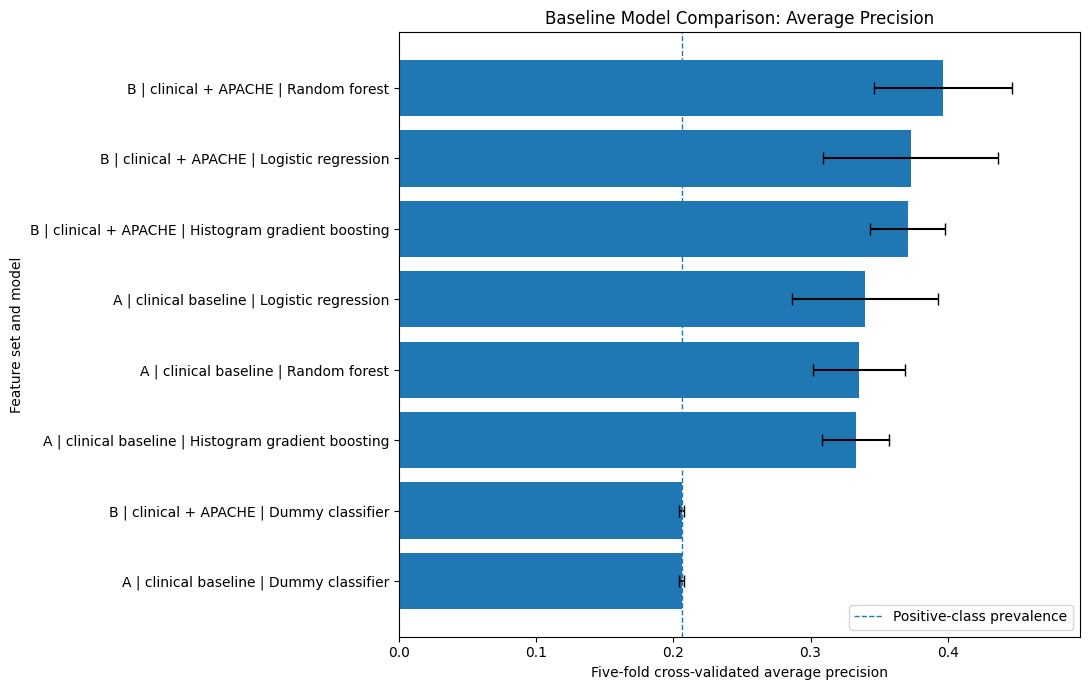

In [93]:
fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.barh(
    plot_average_precision[
        "model_label"
    ],
    plot_average_precision[
        "average_precision_mean"
    ],
    xerr=plot_average_precision[
        "average_precision_std"
    ],
    capsize=4,
)

ax.axvline(
    Y_DEVELOPMENT.mean(),
    linestyle="--",
    linewidth=1,
    label=(
        "Positive-class prevalence"
    ),
)

ax.set_xlabel(
    "Five-fold cross-validated average precision"
)

ax.set_ylabel(
    "Feature set and model"
)

ax.set_title(
    "Baseline Model Comparison: Average Precision"
)

ax.set_xlim(
    0,
    min(
        1.0,
        max(
            plot_average_precision[
                "average_precision_mean"
            ].max() + 0.10,
            0.40,
        ),
    ),
)

ax.legend()

fig.tight_layout()


AVERAGE_PRECISION_FIGURE = (
    MODELING_FIGURE_DIR
    / "baseline_average_precision_comparison.png"
)

fig.savefig(
    AVERAGE_PRECISION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Creating the ROC-AUC comparison figure

In [94]:
plot_roc_auc = (
    baseline_summary
    .sort_values(
        "roc_auc_mean",
        ascending=True,
    )
    .copy()
)


plot_roc_auc["model_label"] = (
    plot_roc_auc[
        "feature_set"
    ]
    .str.replace(
        "Model A: ",
        "A | ",
        regex=False,
    )
    .str.replace(
        "Model B: ",
        "B | ",
        regex=False,
    )
    + " | "
    + plot_roc_auc["model"]
)

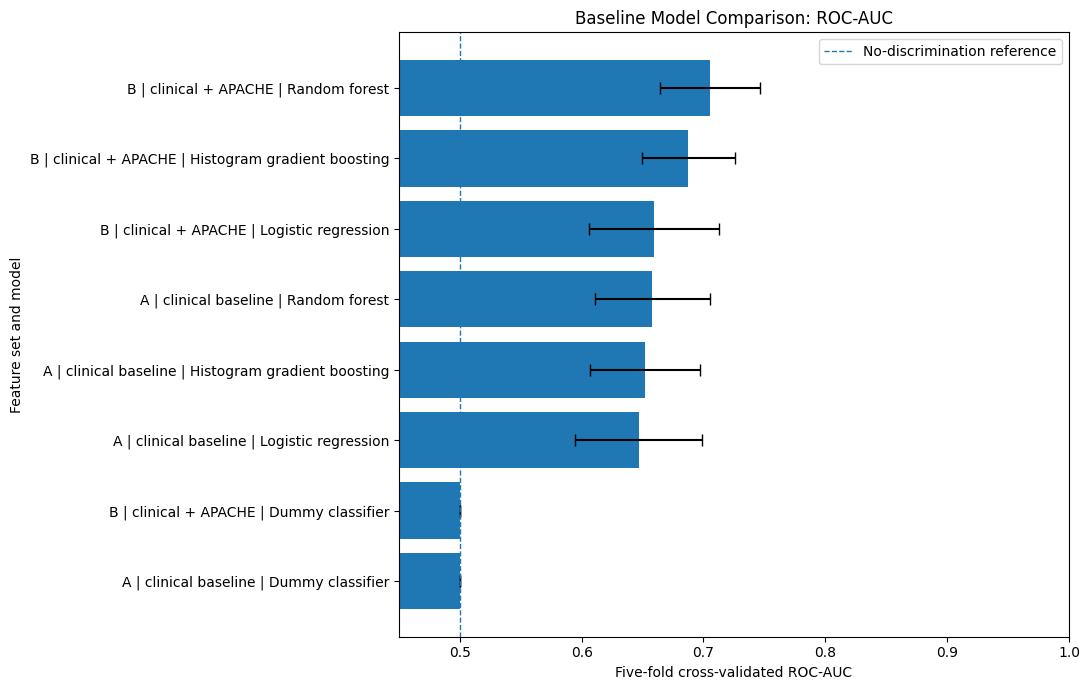

In [95]:
fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.barh(
    plot_roc_auc["model_label"],
    plot_roc_auc["roc_auc_mean"],
    xerr=plot_roc_auc["roc_auc_std"],
    capsize=4,
)

ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="No-discrimination reference",
)

ax.set_xlabel(
    "Five-fold cross-validated ROC-AUC"
)

ax.set_ylabel(
    "Feature set and model"
)

ax.set_title(
    "Baseline Model Comparison: ROC-AUC"
)

ax.set_xlim(0.45, 1.0)

ax.legend()

fig.tight_layout()


ROC_AUC_FIGURE = (
    MODELING_FIGURE_DIR
    / "baseline_roc_auc_comparison.png"
)

fig.savefig(
    ROC_AUC_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Baseline checkpoint

In [96]:
best_baseline_row = (
    baseline_summary.iloc[0]
)


print("BASELINE MODELLING CHECKPOINT")
print("-" * 60)

print(
    "Best feature set:",
    best_baseline_row[
        "feature_set"
    ],
)

print(
    "Best model:",
    best_baseline_row["model"],
)

print(
    "Average precision:",
    (
        f"{best_baseline_row['average_precision_mean']:.4f} "
        f"± "
        f"{best_baseline_row['average_precision_std']:.4f}"
    ),
)

print(
    "ROC-AUC:",
    (
        f"{best_baseline_row['roc_auc_mean']:.4f} "
        f"± "
        f"{best_baseline_row['roc_auc_std']:.4f}"
    ),
)

print(
    "Sensitivity at default threshold:",
    (
        f"{best_baseline_row['sensitivity_mean']:.4f}"
    ),
)

print(
    "Specificity at default threshold:",
    (
        f"{best_baseline_row['specificity_mean']:.4f}"
    ),
)

print(
    "Brier score:",
    (
        f"{best_baseline_row['brier_score_mean']:.4f}"
    ),
)

print("\nThe sealed test set has not been used.")

BASELINE MODELLING CHECKPOINT
------------------------------------------------------------
Best feature set: Model B: clinical + APACHE
Best model: Random forest
Average precision: 0.3964 ± 0.0503
ROC-AUC: 0.7051 ± 0.0410
Sensitivity at default threshold: 0.0526
Specificity at default threshold: 0.9921
Brier score: 0.1565

The sealed test set has not been used.


### Targeted tuning
#### Imports

In [97]:
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    cross_val_predict,
)

### Tuning elastic-net logistic regression

In [98]:
logistic_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            create_linear_preprocessor(
                MODEL_B_BASELINE_NUMERIC,
                MODEL_B_BASELINE_CATEGORICAL,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=10_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

#### Defining a focused search space

In [99]:
LOGISTIC_PARAMETER_DISTRIBUTIONS = {
    "classifier__C": [
        0.001,
        0.003,
        0.01,
        0.03,
        0.1,
        0.3,
        1.0,
        3.0,
        10.0,
        30.0,
    ],

    "classifier__l1_ratio": [
        0.0,
        0.1,
        0.25,
        0.5,
        0.75,
        0.9,
        1.0,
    ],

    "classifier__class_weight": [
        None,
        "balanced",
    ],
}

#### Running the search

In [100]:
logistic_search = RandomizedSearchCV(
    estimator=logistic_tuning_pipeline,
    param_distributions=(
        LOGISTIC_PARAMETER_DISTRIBUTIONS
    ),
    n_iter=35,
    scoring=BASELINE_SCORING,
    refit="average_precision",
    cv=BASELINE_CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise",
)

logistic_search.fit(
    X_DEVELOPMENT_B,
    Y_DEVELOPMENT,
)

Fitting 5 folds for each of 35 candidates, totalling 175 fits


,estimator,Pipeline(step...ver='saga'))])
,param_distributions,"{'classifier__C': [0.001, 0.003, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__l1_ratio': [0.0, 0.1, ...]}"
,n_iter,35
,scoring,"{'average_precision': 'average_precision', 'balanced_accuracy': 'balanced_accuracy', 'f1': 'f1', 'neg_brier_score': 'neg_brier_score', ...}"
,n_jobs,-1
,refit,'average_precision'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,'raise'


#### Inspecting the result

In [101]:
print("Best logistic parameters:")
print(logistic_search.best_params_)

print(
    "Best logistic CV average precision:",
    f"{logistic_search.best_score_:.4f}",
)

Best logistic parameters:
{'classifier__l1_ratio': 1.0, 'classifier__class_weight': 'balanced', 'classifier__C': 0.1}
Best logistic CV average precision: 0.4299


### Tuning random forest

In [ ]:
random_forest_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            create_sparse_tree_preprocessor(
                MODEL_B_BASELINE_NUMERIC,
                MODEL_B_BASELINE_CATEGORICAL,
            ),
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

#### Defining the search

In [103]:
RANDOM_FOREST_PARAMETER_DISTRIBUTIONS = {
    "classifier__n_estimators": [
        300,
        500,
        700,
        900,
    ],

    "classifier__max_depth": [
        None,
        5,
        8,
        12,
        16,
        24,
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10,
        20,
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        3,
        5,
        8,
        12,
    ],

    "classifier__max_features": [
        "sqrt",
        "log2",
        0.25,
        0.40,
        0.60,
    ],

    "classifier__class_weight": [
        None,
        "balanced",
        "balanced_subsample",
    ],

    "classifier__bootstrap": [
        True,
    ],
}

#### Running the search

In [ ]:
random_forest_search = RandomizedSearchCV(
    estimator=random_forest_tuning_pipeline,
    param_distributions=(
        RANDOM_FOREST_PARAMETER_DISTRIBUTIONS
    ),
    n_iter=40,
    scoring=BASELINE_SCORING,
    refit="average_precision",
    cv=BASELINE_CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,       # In case of multiprocessing causes a memory or process error, n_jobs=1
    verbose=1,
    return_train_score=True,
    error_score="raise",
)

random_forest_search.fit(
    X_DEVELOPMENT_B,
    Y_DEVELOPMENT,
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__bootstrap': [True], 'classifier__class_weight': [None, 'balanced', ...], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,40
,scoring,"{'average_precision': 'average_precision', 'balanced_accuracy': 'balanced_accuracy', 'f1': 'f1', 'neg_brier_score': 'neg_brier_score', ...}"
,n_jobs,-1
,refit,'average_precision'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,'raise'


#### Inspecting

In [105]:
print("Best random-forest parameters:")
print(random_forest_search.best_params_)

print(
    "Best random-forest CV average precision:",
    f"{random_forest_search.best_score_:.4f}",
)

Best random-forest parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 0.25, 'classifier__max_depth': 5, 'classifier__class_weight': 'balanced', 'classifier__bootstrap': True}
Best random-forest CV average precision: 0.4018


### Saving complete tuning results

In [106]:
logistic_tuning_results = pd.DataFrame(
    logistic_search.cv_results_
)

random_forest_tuning_results = pd.DataFrame(
    random_forest_search.cv_results_
)

In [107]:
LOGISTIC_TUNING_FILE = (
    METRIC_DIR
    / "logistic_randomized_search_results.csv"
)

RANDOM_FOREST_TUNING_FILE = (
    METRIC_DIR
    / "random_forest_randomized_search_results.csv"
)


logistic_tuning_results.to_csv(
    LOGISTIC_TUNING_FILE,
    index=False,
)

random_forest_tuning_results.to_csv(
    RANDOM_FOREST_TUNING_FILE,
    index=False,
)

#### Saving the best settings

In [108]:
best_parameter_summary = {
    "selection_metric": "average_precision",

    "logistic_regression": {
        "best_average_precision": float(
            logistic_search.best_score_
        ),
        "best_parameters": (
            logistic_search.best_params_
        ),
    },

    "random_forest": {
        "best_average_precision": float(
            random_forest_search.best_score_
        ),
        "best_parameters": (
            random_forest_search.best_params_
        ),
    },
}

In [109]:
BEST_PARAMETER_FILE = (
    MODEL_DIR
    / "best_tuned_model_parameters.json"
)

with BEST_PARAMETER_FILE.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        best_parameter_summary,
        file,
        indent=2,
    )

### Generating out-of-fold tuned probabilities

In [110]:
best_logistic_pipeline = (
    logistic_search.best_estimator_
)

best_random_forest_pipeline = (
    random_forest_search.best_estimator_
)

In [111]:
logistic_oof_probability = cross_val_predict(
    estimator=best_logistic_pipeline,
    X=X_DEVELOPMENT_B,
    y=Y_DEVELOPMENT,
    cv=BASELINE_CV,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

In [112]:
random_forest_oof_probability = (
    cross_val_predict(
        estimator=best_random_forest_pipeline,
        X=X_DEVELOPMENT_B,
        y=Y_DEVELOPMENT,
        cv=BASELINE_CV,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]
)

#### Validating

In [113]:
assert len(
    logistic_oof_probability
) == len(Y_DEVELOPMENT)

assert len(
    random_forest_oof_probability
) == len(Y_DEVELOPMENT)

assert np.isfinite(
    logistic_oof_probability
).all()

assert np.isfinite(
    random_forest_oof_probability
).all()

assert (
    (logistic_oof_probability >= 0)
    & (logistic_oof_probability <= 1)
).all()

assert (
    (random_forest_oof_probability >= 0)
    & (random_forest_oof_probability <= 1)
).all()

#### Saving them

In [114]:
oof_predictions = pd.DataFrame(
    {
        "patientunitstayid": (
            development_data[
                "patientunitstayid"
            ].to_numpy()
        ),
        "observed_outcome": (
            Y_DEVELOPMENT.to_numpy()
        ),
        "logistic_probability": (
            logistic_oof_probability
        ),
        "random_forest_probability": (
            random_forest_oof_probability
        ),
    }
)

In [115]:
PRIVATE_OOF_FILE = (
    SPLIT_DIR
    / "tuned_model_oof_predictions.csv"
)

oof_predictions.to_csv(
    PRIVATE_OOF_FILE,
    index=False,
)

### Comparing tuned development discrimination

In [116]:
def calculate_probability_metrics(
    observed: pd.Series,
    probabilities: np.ndarray,
    model_name: str,
) -> dict[str, float | str]:
    return {
        "model": model_name,

        "average_precision": (
            average_precision_score(
                observed,
                probabilities,
            )
        ),

        "roc_auc": (
            roc_auc_score(
                observed,
                probabilities,
            )
        ),

        "brier_score": (
            brier_score_loss(
                observed,
                probabilities,
            )
        ),
    }

In [117]:
tuned_oof_summary = pd.DataFrame(
    [
        calculate_probability_metrics(
            Y_DEVELOPMENT,
            logistic_oof_probability,
            "Elastic-net logistic regression",
        ),

        calculate_probability_metrics(
            Y_DEVELOPMENT,
            random_forest_oof_probability,
            "Random forest",
        ),
    ]
)

In [118]:
display(
    tuned_oof_summary.round(4)
)

,model,average_precision,roc_auc,brier_score
0,Elastic-net logistic regression,0.4082,0.7149,0.2095
1,Random forest,0.3875,0.7176,0.1719


#### Saving the parameters

In [119]:
TUNED_OOF_SUMMARY_FILE = (
    METRIC_DIR
    / "tuned_model_oof_probability_metrics.csv"
)

tuned_oof_summary.to_csv(
    TUNED_OOF_SUMMARY_FILE,
    index=False,
)

### Calculating candidate probability thresholds

In [120]:
def calculate_threshold_metrics(
    observed: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
) -> dict[str, float | int]:
    predicted = (
        probabilities >= threshold
    ).astype("int8")

    tn, fp, fn, tp = confusion_matrix(
        observed,
        predicted,
        labels=[0, 1],
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    return {
        "threshold": threshold,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "negative_predictive_value": (
            negative_predictive_value
        ),
        "f1": f1_score(
            observed,
            predicted,
            zero_division=0,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                observed,
                predicted,
            )
        ),
    }

#### Candidate-threshold finder

In [121]:
def identify_candidate_thresholds(
    observed: pd.Series,
    probabilities: np.ndarray,
) -> dict[str, float]:
    # Youden index
    fpr, tpr, roc_thresholds = roc_curve(
        observed,
        probabilities,
    )

    youden_index = tpr - fpr

    youden_threshold = float(
        roc_thresholds[
            np.nanargmax(youden_index)
        ]
    )

    # Maximum F1
    precision, recall, pr_thresholds = (
        precision_recall_curve(
            observed,
            probabilities,
        )
    )

    f1_values = (
        2
        * precision[:-1]
        * recall[:-1]
        / (
            precision[:-1]
            + recall[:-1]
            + 1e-12
        )
    )

    maximum_f1_threshold = float(
        pr_thresholds[
            np.nanargmax(f1_values)
        ]
    )

    candidate_thresholds = {
        "default_0.50": 0.50,
        "maximum_youden": (
            youden_threshold
        ),
        "maximum_f1": (
            maximum_f1_threshold
        ),
    }

    unique_thresholds = np.unique(
        probabilities
    )

    for target_sensitivity in (
        0.70,
        0.80,
    ):
        eligible_thresholds = []

        for threshold in unique_thresholds:
            metrics = (
                calculate_threshold_metrics(
                    observed,
                    probabilities,
                    float(threshold),
                )
            )

            if (
                metrics["sensitivity"]
                >= target_sensitivity
            ):
                eligible_thresholds.append(
                    (
                        threshold,
                        metrics["specificity"],
                    )
                )

        if eligible_thresholds:
            selected_threshold = max(
                eligible_thresholds,
                key=lambda item: (
                    item[1],
                    item[0],
                ),
            )[0]

            candidate_thresholds[
                (
                    "sensitivity_at_least_"
                    f"{int(target_sensitivity * 100)}"
                )
            ] = float(
                selected_threshold
            )

    return candidate_thresholds

#### Building the table

In [122]:
def create_threshold_comparison(
    observed: pd.Series,
    probabilities: np.ndarray,
    model_name: str,
) -> pd.DataFrame:
    threshold_definitions = (
        identify_candidate_thresholds(
            observed,
            probabilities,
        )
    )

    rows = []

    for (
        threshold_name,
        threshold,
    ) in threshold_definitions.items():
        metrics = calculate_threshold_metrics(
            observed,
            probabilities,
            threshold,
        )

        rows.append(
            {
                "model": model_name,
                "threshold_method": (
                    threshold_name
                ),
                **metrics,
            }
        )

    return pd.DataFrame(rows)

In [123]:
threshold_comparison = pd.concat(
    [
        create_threshold_comparison(
            Y_DEVELOPMENT,
            logistic_oof_probability,
            "Elastic-net logistic regression",
        ),

        create_threshold_comparison(
            Y_DEVELOPMENT,
            random_forest_oof_probability,
            "Random forest",
        ),
    ],
    ignore_index=True,
)

In [124]:
display(
    threshold_comparison[
        [
            "model",
            "threshold_method",
            "threshold",
            "sensitivity",
            "specificity",
            "precision",
            "negative_predictive_value",
            "f1",
            "balanced_accuracy",
        ]
    ].round(4)
)

,model,threshold_method,threshold,sensitivity,specificity,precision,negative_predictive_value,f1,balanced_accuracy
0,Elastic-net logistic regression,default_0.50,0.5000,0.6419,0.6916,0.3508,0.8815,0.4537,0.6668
1,Elastic-net logistic regression,maximum_youden,0.4575,0.7162,0.6429,0.3424,0.8972,0.4633,0.6795
2,Elastic-net logistic regression,maximum_f1,0.4575,0.7162,0.6429,0.3424,0.8972,0.4633,0.6795
3,Elastic-net logistic regression,sensitivity_at_least_70,0.4603,0.7031,0.6463,0.3404,0.8934,0.4587,0.6747
4,Elastic-net logistic regression,sensitivity_at_least_80,0.3667,0.8035,0.4807,0.2866,0.9041,0.4225,0.6421
5,Random forest,default_0.50,0.5000,0.4061,0.8492,0.4115,0.8463,0.4088,0.6277
6,Random forest,maximum_youden,0.3588,0.7467,0.6224,0.3393,0.9044,0.4666,0.6846
7,Random forest,maximum_f1,0.3799,0.6987,0.6689,0.3540,0.8953,0.4699,0.6838
8,Random forest,sensitivity_at_least_70,0.3760,0.7031,0.6576,0.3477,0.8951,0.4653,0.6803
9,Random forest,sensitivity_at_least_80,0.3167,0.8035,0.5193,0.3026,0.9105,0.4397,0.6614


#### Saving them

In [125]:
THRESHOLD_COMPARISON_FILE = (
    METRIC_DIR
    / "development_threshold_comparison.csv"
)

threshold_comparison.to_csv(
    THRESHOLD_COMPARISON_FILE,
    index=False,
)

### Creating the tuned precision-recall figure

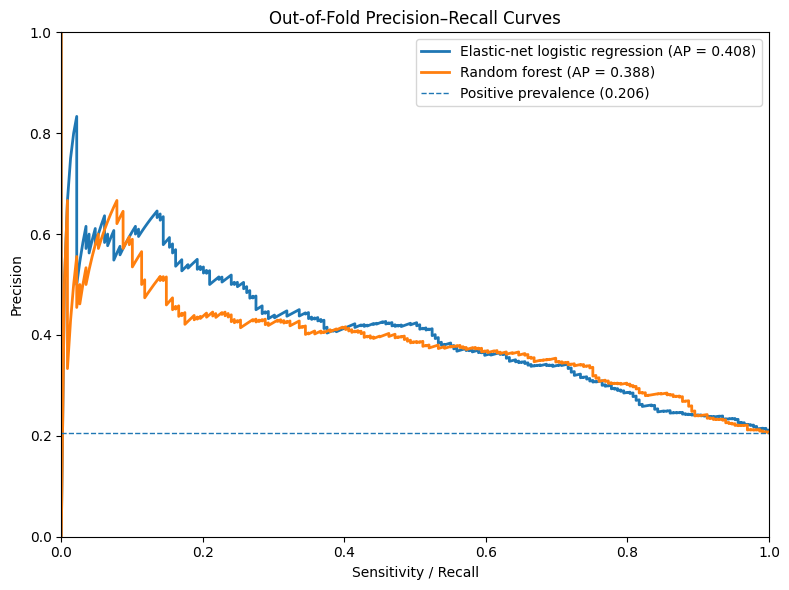

In [126]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

for model_name, probabilities in {
    "Elastic-net logistic regression": (
        logistic_oof_probability
    ),
    "Random forest": (
        random_forest_oof_probability
    ),
}.items():

    precision, recall, _ = (
        precision_recall_curve(
            Y_DEVELOPMENT,
            probabilities,
        )
    )

    average_precision = (
        average_precision_score(
            Y_DEVELOPMENT,
            probabilities,
        )
    )

    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AP = {average_precision:.3f})"
        ),
    )


ax.axhline(
    Y_DEVELOPMENT.mean(),
    linestyle="--",
    linewidth=1,
    label=(
        "Positive prevalence "
        f"({Y_DEVELOPMENT.mean():.3f})"
    ),
)

ax.set_xlabel("Sensitivity / Recall")
ax.set_ylabel("Precision")
ax.set_title(
    "Out-of-Fold Precision–Recall Curves"
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="best")

fig.tight_layout()


TUNED_PR_FIGURE = (
    MODELING_FIGURE_DIR
    / "tuned_oof_precision_recall_curves.png"
)

fig.savefig(
    TUNED_PR_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Creating the tuned ROC figure

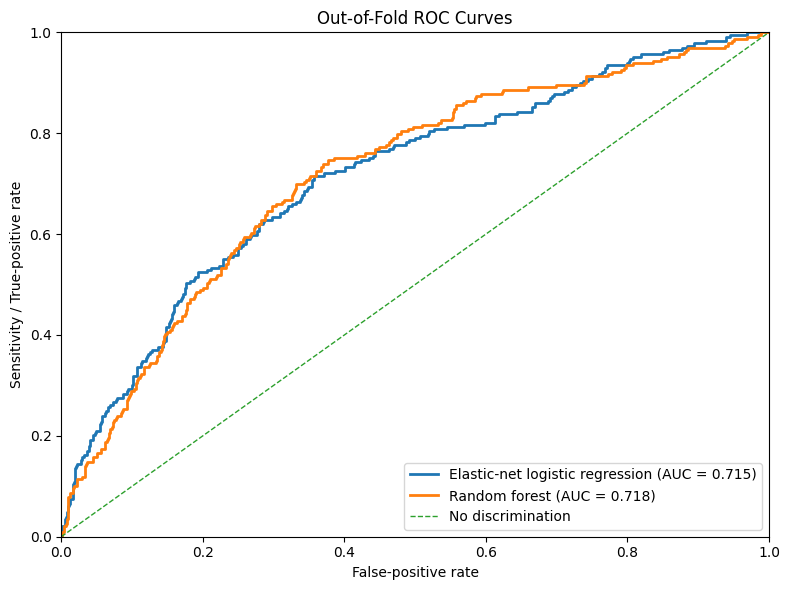

In [127]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

for model_name, probabilities in {
    "Elastic-net logistic regression": (
        logistic_oof_probability
    ),
    "Random forest": (
        random_forest_oof_probability
    ),
}.items():

    fpr, tpr, _ = roc_curve(
        Y_DEVELOPMENT,
        probabilities,
    )

    roc_auc = roc_auc_score(
        Y_DEVELOPMENT,
        probabilities,
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {roc_auc:.3f})"
        ),
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="No discrimination",
)

ax.set_xlabel("False-positive rate")
ax.set_ylabel("Sensitivity / True-positive rate")
ax.set_title(
    "Out-of-Fold ROC Curves"
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="lower right")

fig.tight_layout()


TUNED_ROC_FIGURE = (
    MODELING_FIGURE_DIR
    / "tuned_oof_roc_curves.png"
)

fig.savefig(
    TUNED_ROC_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Probability calibration and final model lock
#### Imports

In [128]:
from sklearn.base import clone
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)
from sklearn.metrics import log_loss

#### Defining the inner calibration folds

In [129]:
CALIBRATION_CV = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

#### Creating a version-compatible calibrator

In [130]:
def create_sigmoid_calibrator(
    estimator,
) -> CalibratedClassifierCV:
    """
    Create a sigmoid probability calibrator compatible with
    old and new scikit-learn versions.
    """

    calibration_parameters = {
        "method": "sigmoid",
        "cv": CALIBRATION_CV,
    }

    calibrator_signature = inspect.signature(
        CalibratedClassifierCV
    )

    if (
        "estimator"
        in calibrator_signature.parameters
    ):
        calibration_parameters[
            "estimator"
        ] = clone(estimator)

    else:
        calibration_parameters[
            "base_estimator"
        ] = clone(estimator)

    if (
        "n_jobs"
        in calibrator_signature.parameters
    ):
        calibration_parameters[
            "n_jobs"
        ] = 1

    return CalibratedClassifierCV(
        **calibration_parameters
    )

#### Creating both calibrated candidates

In [131]:
calibrated_logistic_pipeline = (
    create_sigmoid_calibrator(
        best_logistic_pipeline
    )
)

calibrated_random_forest_pipeline = (
    create_sigmoid_calibrator(
        best_random_forest_pipeline
    )
)

#### Generating calibrated OOF probabilities

In [132]:
calibrated_logistic_oof_probability = (
    cross_val_predict(
        estimator=calibrated_logistic_pipeline,
        X=X_DEVELOPMENT_B,
        y=Y_DEVELOPMENT,
        cv=BASELINE_CV,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]
)

In [133]:
calibrated_random_forest_oof_probability = (
    cross_val_predict(
        estimator=calibrated_random_forest_pipeline,
        X=X_DEVELOPMENT_B,
        y=Y_DEVELOPMENT,
        cv=BASELINE_CV,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]
)

#### Validating the results

In [134]:
for model_probability in (
    calibrated_logistic_oof_probability,
    calibrated_random_forest_oof_probability,
):
    assert len(model_probability) == len(
        Y_DEVELOPMENT
    )

    assert np.isfinite(
        model_probability
    ).all()

    assert (
        (model_probability >= 0)
        & (model_probability <= 1)
    ).all()


print(
    "Nested out-of-fold calibration completed."
)

Nested out-of-fold calibration completed.


### Calculating calibration metrics
#### Adding a quantile-based expected calibration error

In [135]:
def expected_calibration_error(
    observed: pd.Series,
    probabilities: np.ndarray,
    n_bins: int = 10,
) -> float:
    """
    Calculate a quantile-binned expected calibration error.
    """

    calibration_data = pd.DataFrame(
        {
            "observed": np.asarray(
                observed
            ),
            "probability": probabilities,
        }
    )

    number_of_unique_probabilities = (
        calibration_data[
            "probability"
        ].nunique()
    )

    effective_bins = min(
        n_bins,
        number_of_unique_probabilities,
    )

    calibration_data["bin"] = pd.qcut(
        calibration_data["probability"],
        q=effective_bins,
        duplicates="drop",
    )

    bin_summary = (
        calibration_data
        .groupby(
            "bin",
            observed=False,
        )
        .agg(
            bin_size=(
                "observed",
                "size",
            ),
            observed_rate=(
                "observed",
                "mean",
            ),
            predicted_rate=(
                "probability",
                "mean",
            ),
        )
        .reset_index()
    )

    calibration_error = (
        (
            bin_summary["bin_size"]
            / len(calibration_data)
        )
        * (
            bin_summary["observed_rate"]
            - bin_summary["predicted_rate"]
        ).abs()
    ).sum()

    return float(calibration_error)

#### Creating an extended metric function

In [136]:
def calculate_extended_probability_metrics(
    observed: pd.Series,
    probabilities: np.ndarray,
    model_name: str,
    calibration_status: str,
) -> dict[str, object]:
    return {
        "model": model_name,
        "calibration_status": (
            calibration_status
        ),

        "average_precision": (
            average_precision_score(
                observed,
                probabilities,
            )
        ),

        "roc_auc": (
            roc_auc_score(
                observed,
                probabilities,
            )
        ),

        "brier_score": (
            brier_score_loss(
                observed,
                probabilities,
            )
        ),

        "log_loss": (
            log_loss(
                observed,
                probabilities,
                labels=[0, 1],
            )
        ),

        "expected_calibration_error": (
            expected_calibration_error(
                observed,
                probabilities,
                n_bins=10,
            )
        ),

        "mean_predicted_probability": (
            float(
                np.mean(probabilities)
            )
        ),

        "observed_positive_rate": (
            float(
                np.mean(observed)
            )
        ),
    }

#### Comparing four variants

In [137]:
calibration_comparison = pd.DataFrame(
    [
        calculate_extended_probability_metrics(
            Y_DEVELOPMENT,
            logistic_oof_probability,
            "Elastic-net logistic regression",
            "Uncalibrated",
        ),

        calculate_extended_probability_metrics(
            Y_DEVELOPMENT,
            calibrated_logistic_oof_probability,
            "Elastic-net logistic regression",
            "Sigmoid calibrated",
        ),

        calculate_extended_probability_metrics(
            Y_DEVELOPMENT,
            random_forest_oof_probability,
            "Random forest",
            "Uncalibrated",
        ),

        calculate_extended_probability_metrics(
            Y_DEVELOPMENT,
            calibrated_random_forest_oof_probability,
            "Random forest",
            "Sigmoid calibrated",
        ),
    ]
)

#### Displaying them

In [138]:
display(
    calibration_comparison.round(4)
)

,model,calibration_status,average_precision,roc_auc,brier_score,log_loss,expected_calibration_error,mean_predicted_probability,observed_positive_rate
0,Elastic-net logistic regression,Uncalibrated,0.4082,0.7149,0.2095,0.6085,0.2370,0.4431,0.2061
1,Elastic-net logistic regression,Sigmoid calibrated,0.4032,0.7137,0.1476,0.4622,0.0292,0.2080,0.2061
2,Random forest,Uncalibrated,0.3875,0.7176,0.1719,0.5239,0.1552,0.3614,0.2061
3,Random forest,Sigmoid calibrated,0.3761,0.7144,0.1485,0.4637,0.0389,0.2081,0.2061


#### Saving them

In [139]:
CALIBRATION_COMPARISON_FILE = (
    METRIC_DIR
    / "development_calibration_comparison.csv"
)

calibration_comparison.to_csv(
    CALIBRATION_COMPARISON_FILE,
    index=False,
)

### Creating the calibration plot

In [140]:
probability_candidates = {
    "Logistic — uncalibrated":
        logistic_oof_probability,

    "Logistic — calibrated":
        calibrated_logistic_oof_probability,

    "Random forest — uncalibrated":
        random_forest_oof_probability,

    "Random forest — calibrated":
        calibrated_random_forest_oof_probability,
}

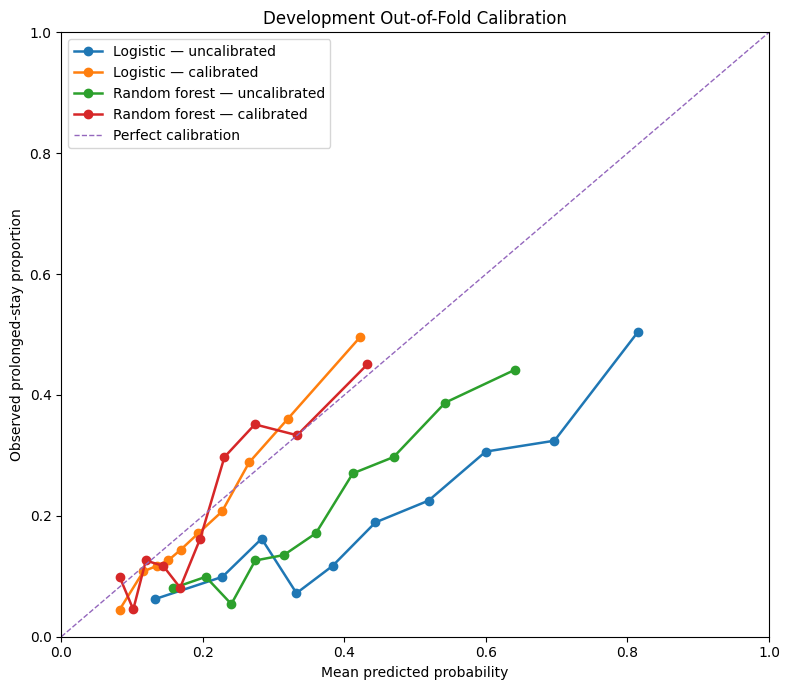

In [141]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)

for (
    model_label,
    probabilities,
) in probability_candidates.items():

    observed_fraction, predicted_mean = (
        calibration_curve(
            Y_DEVELOPMENT,
            probabilities,
            n_bins=10,
            strategy="quantile",
        )
    )

    ax.plot(
        predicted_mean,
        observed_fraction,
        marker="o",
        linewidth=1.8,
        label=model_label,
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfect calibration",
)

ax.set_xlabel(
    "Mean predicted probability"
)

ax.set_ylabel(
    "Observed prolonged-stay proportion"
)

ax.set_title(
    "Development Out-of-Fold Calibration"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="best")

fig.tight_layout()


CALIBRATION_FIGURE = (
    MODELING_FIGURE_DIR
    / "development_oof_calibration.png"
)

fig.savefig(
    CALIBRATION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Recalculating thresholds using calibrated probabilities

In [142]:
calibrated_threshold_comparison = (
    pd.concat(
        [
            create_threshold_comparison(
                Y_DEVELOPMENT,
                calibrated_logistic_oof_probability,
                (
                    "Sigmoid-calibrated "
                    "elastic-net logistic regression"
                ),
            ),

            create_threshold_comparison(
                Y_DEVELOPMENT,
                calibrated_random_forest_oof_probability,
                (
                    "Sigmoid-calibrated "
                    "random forest"
                ),
            ),
        ],
        ignore_index=True,
    )
)

#### Displaying them

In [143]:
display(
    calibrated_threshold_comparison[
        [
            "model",
            "threshold_method",
            "threshold",
            "sensitivity",
            "specificity",
            "precision",
            "negative_predictive_value",
            "f1",
            "balanced_accuracy",
        ]
    ].round(4)
)

,model,threshold_method,threshold,sensitivity,specificity,precision,negative_predictive_value,f1,balanced_accuracy
0,Sigmoid-calibrated elastic-net logistic regres...,default_0.50,0.5000,0.0393,0.9966,0.7500,0.7998,0.0747,0.5179
1,Sigmoid-calibrated elastic-net logistic regres...,maximum_youden,0.1987,0.6987,0.6440,0.3376,0.8917,0.4552,0.6713
2,Sigmoid-calibrated elastic-net logistic regres...,maximum_f1,0.2460,0.5546,0.7744,0.3896,0.8701,0.4577,0.6645
3,Sigmoid-calibrated elastic-net logistic regres...,sensitivity_at_least_70,0.1952,0.7031,0.6281,0.3292,0.8907,0.4485,0.6656
4,Sigmoid-calibrated elastic-net logistic regres...,sensitivity_at_least_80,0.1626,0.8035,0.4728,0.2835,0.9026,0.4191,0.6381
5,Sigmoid-calibrated random forest,default_0.50,0.5000,0.0218,0.9932,0.4545,0.7964,0.0417,0.5075
6,Sigmoid-calibrated random forest,maximum_youden,0.2050,0.7205,0.6565,0.3526,0.9005,0.4735,0.6885
7,Sigmoid-calibrated random forest,maximum_f1,0.2267,0.6550,0.7154,0.3741,0.8887,0.4762,0.6852
8,Sigmoid-calibrated random forest,sensitivity_at_least_70,0.2085,0.7031,0.6655,0.3531,0.8962,0.4701,0.6843
9,Sigmoid-calibrated random forest,sensitivity_at_least_80,0.1623,0.8035,0.4932,0.2916,0.9062,0.4279,0.6483


#### Saving them

In [144]:
CALIBRATED_THRESHOLD_FILE = (
    METRIC_DIR
    / "development_calibrated_threshold_comparison.csv"
)

calibrated_threshold_comparison.to_csv(
    CALIBRATED_THRESHOLD_FILE,
    index=False,
)

### Creating a focused threshold figure

In [145]:
threshold_plot_data = (
    calibrated_threshold_comparison.loc[
        calibrated_threshold_comparison[
            "threshold_method"
        ].isin(
            [
                "maximum_youden",
                "maximum_f1",
                "sensitivity_at_least_70",
                "sensitivity_at_least_80",
            ]
        )
    ]
    .copy()
)

In [146]:
threshold_plot_data[
    "operating_point"
] = (
    threshold_plot_data[
        "model"
    ]
    .str.replace(
        "Sigmoid-calibrated ",
        "",
        regex=False,
    )
    + " | "
    + threshold_plot_data[
        "threshold_method"
    ]
    .str.replace(
        "_",
        " ",
        regex=False,
    )
)

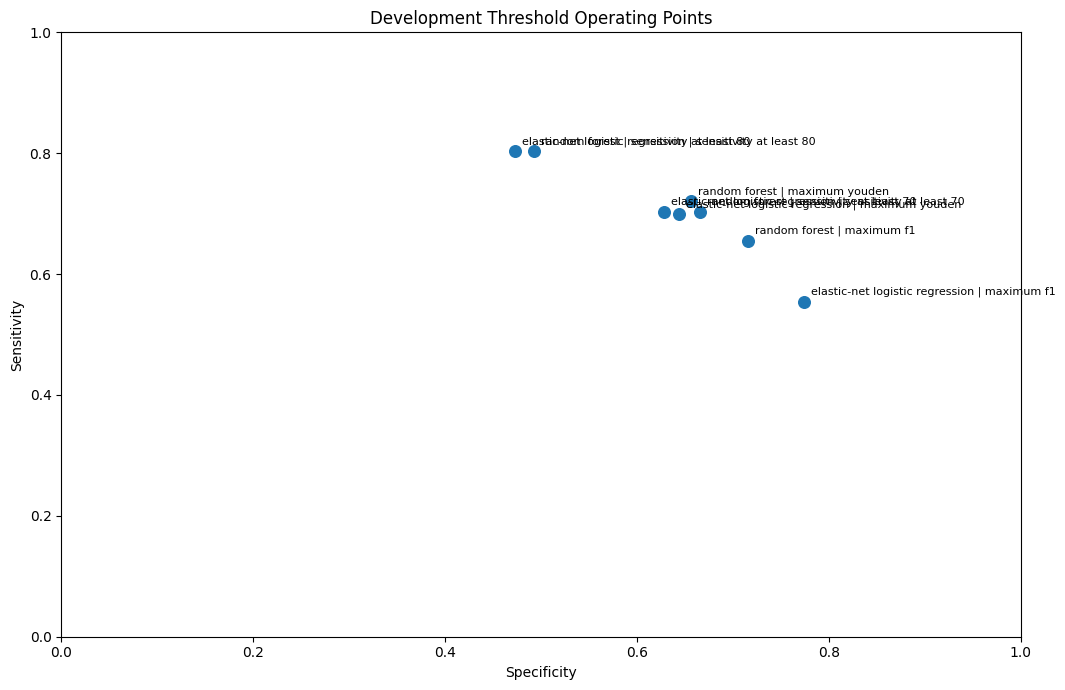

In [147]:
fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.scatter(
    threshold_plot_data[
        "specificity"
    ],
    threshold_plot_data[
        "sensitivity"
    ],
    s=70,
)

for _, row in (
    threshold_plot_data.iterrows()
):
    ax.annotate(
        row["operating_point"],
        (
            row["specificity"],
            row["sensitivity"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Specificity")
ax.set_ylabel("Sensitivity")

ax.set_title(
    "Development Threshold Operating Points"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.tight_layout()


THRESHOLD_FIGURE = (
    MODELING_FIGURE_DIR
    / "development_threshold_operating_points.png"
)

fig.savefig(
    THRESHOLD_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Saving calibrated OOF probabilities locally

In [148]:
calibrated_oof_predictions = pd.DataFrame(
    {
        "patientunitstayid": (
            development_data[
                "patientunitstayid"
            ].to_numpy()
        ),

        "observed_outcome": (
            Y_DEVELOPMENT.to_numpy()
        ),

        "calibrated_logistic_probability": (
            calibrated_logistic_oof_probability
        ),

        "calibrated_random_forest_probability": (
            calibrated_random_forest_oof_probability
        ),
    }
)

In [149]:
PRIVATE_CALIBRATED_OOF_FILE = (
    SPLIT_DIR
    / "calibrated_model_oof_predictions.csv"
)

calibrated_oof_predictions.to_csv(
    PRIVATE_CALIBRATED_OOF_FILE,
    index=False,
)

### Saving the model lock before opening the test set

In [150]:
FINAL_PRIMARY_MODEL_NAME = (
    "Sigmoid-calibrated L1 logistic regression"
)

FINAL_SECONDARY_MODEL_NAME = (
    "Sigmoid-calibrated random forest"
)

FINAL_PRIMARY_THRESHOLD = 0.195239
FINAL_SECONDARY_THRESHOLD = 0.208464

FINAL_FEATURE_SET_NAME = (
    "Model B: clinical + APACHE"
)


final_model_lock = {
    "primary_model": {
        "name": FINAL_PRIMARY_MODEL_NAME,
        "feature_set": FINAL_FEATURE_SET_NAME,
        "calibration": "sigmoid",
        "threshold": FINAL_PRIMARY_THRESHOLD,
        "threshold_selection_rule": (
            "Highest specificity subject to "
            "development sensitivity >= 0.70"
        ),
        "parameters": (
            logistic_search.best_params_
        ),
    },

    "secondary_model": {
        "name": FINAL_SECONDARY_MODEL_NAME,
        "feature_set": FINAL_FEATURE_SET_NAME,
        "calibration": "sigmoid",
        "threshold": FINAL_SECONDARY_THRESHOLD,
        "threshold_selection_rule": (
            "Highest specificity subject to "
            "development sensitivity >= 0.70"
        ),
        "parameters": (
            random_forest_search.best_params_
        ),
    },

    "test_set_status": (
        "Sealed until after this decision was saved"
    ),
}

In [151]:
FINAL_MODEL_LOCK_FILE = (
    MODEL_DIR
    / "final_model_lock_v001.json"
)

with FINAL_MODEL_LOCK_FILE.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_model_lock,
        file,
        indent=2,
    )

print(f"Model lock saved to: {FINAL_MODEL_LOCK_FILE}")

Model lock saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\models\final_model_lock_v001.json


### Preparing the untouched test set

In [152]:
X_TEST_B = prepare_feature_frame(
    dataframe=test_data,
    feature_columns=MODEL_B_BASELINE_FEATURES,
    categorical_columns=MODEL_B_BASELINE_CATEGORICAL,
)

Y_TEST = (
    test_data[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

#### Validating it

In [153]:
assert len(X_TEST_B) == 278
assert len(Y_TEST) == 278
assert int(Y_TEST.sum()) == 57

assert list(
    X_TEST_B.columns
) == list(
    X_DEVELOPMENT_B.columns
)

assert not set(
    development_data["patientunitstayid"]
).intersection(
    set(test_data["patientunitstayid"])
)

print("Untouched test matrix validated.")
print(f"Test rows: {len(X_TEST_B):,}")
print(f"Test positives: {int(Y_TEST.sum()):,}")

Untouched test matrix validated.
Test rows: 278
Test positives: 57


### Fitting the locked models on all development data

In [154]:
import joblib
from sklearn.base import clone

In [155]:
final_primary_model = clone(
    calibrated_logistic_pipeline
)

final_secondary_model = clone(
    calibrated_random_forest_pipeline
)

#### Fitting using only the full development set

In [156]:
final_primary_model.fit(
    X_DEVELOPMENT_B,
    Y_DEVELOPMENT,
)

final_secondary_model.fit(
    X_DEVELOPMENT_B,
    Y_DEVELOPMENT,
)

print("Both locked models fitted on the development set.")

Both locked models fitted on the development set.


#### Saving the fitted models

In [157]:
FINAL_PRIMARY_MODEL_FILE = (
    MODEL_DIR
    / "final_calibrated_logistic_model.joblib"
)

FINAL_SECONDARY_MODEL_FILE = (
    MODEL_DIR
    / "secondary_calibrated_random_forest_model.joblib"
)


joblib.dump(
    final_primary_model,
    FINAL_PRIMARY_MODEL_FILE,
)

joblib.dump(
    final_secondary_model,
    FINAL_SECONDARY_MODEL_FILE,
)


print(f"Primary model: {FINAL_PRIMARY_MODEL_FILE}")
print(f"Secondary model: {FINAL_SECONDARY_MODEL_FILE}")

Primary model: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\models\final_calibrated_logistic_model.joblib
Secondary model: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\models\secondary_calibrated_random_forest_model.joblib


### Generating test probabilities

In [158]:
primary_test_probability = (
    final_primary_model.predict_proba(
        X_TEST_B
    )[:, 1]
)

secondary_test_probability = (
    final_secondary_model.predict_proba(
        X_TEST_B
    )[:, 1]
)

#### Validating them

In [159]:
for probabilities in (
    primary_test_probability,
    secondary_test_probability,
):
    assert len(probabilities) == 278
    assert np.isfinite(probabilities).all()

    assert (
        (probabilities >= 0)
        & (probabilities <= 1)
    ).all()

print("Test probabilities generated successfully.")

Test probabilities generated successfully.


### Calculating final test metrics

In [160]:
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [161]:
def calculate_final_test_metrics(
    observed: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    model_name: str,
) -> dict[str, object]:
    predicted = (
        probabilities >= threshold
    ).astype("int8")

    tn, fp, fn, tp = confusion_matrix(
        observed,
        predicted,
        labels=[0, 1],
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    return {
        "model": model_name,
        "threshold": threshold,

        "test_n": len(observed),
        "positive_n": int(
            np.sum(observed)
        ),

        "roc_auc": roc_auc_score(
            observed,
            probabilities,
        ),

        "average_precision": (
            average_precision_score(
                observed,
                probabilities,
            )
        ),

        "brier_score": (
            brier_score_loss(
                observed,
                probabilities,
            )
        ),

        "log_loss": log_loss(
            observed,
            probabilities,
            labels=[0, 1],
        ),

        "mean_predicted_probability": (
            float(
                np.mean(probabilities)
            )
        ),

        "observed_positive_rate": (
            float(
                np.mean(observed)
            )
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),

        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,

        "negative_predictive_value": (
            negative_predictive_value
        ),

        "f1": f1_score(
            observed,
            predicted,
            zero_division=0,
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                observed,
                predicted,
            )
        ),
    }

#### Evaluating both locked candidates

In [162]:
final_test_metrics = pd.DataFrame(
    [
        calculate_final_test_metrics(
            observed=Y_TEST,
            probabilities=(
                primary_test_probability
            ),
            threshold=(
                FINAL_PRIMARY_THRESHOLD
            ),
            model_name=(
                FINAL_PRIMARY_MODEL_NAME
            ),
        ),

        calculate_final_test_metrics(
            observed=Y_TEST,
            probabilities=(
                secondary_test_probability
            ),
            threshold=(
                FINAL_SECONDARY_THRESHOLD
            ),
            model_name=(
                FINAL_SECONDARY_MODEL_NAME
            ),
        ),
    ]
)

#### Displaying them

In [163]:
display(
    final_test_metrics.round(4)
)

,model,threshold,test_n,positive_n,roc_auc,average_precision,brier_score,log_loss,mean_predicted_probability,observed_positive_rate,true_negative,false_positive,false_negative,true_positive,sensitivity,specificity,precision,negative_predictive_value,f1,balanced_accuracy
0,Sigmoid-calibrated L1 logistic regression,0.1952,278,57,0.7242,0.4120,0.1459,0.4564,0.1975,0.205,153,68,21,36,0.6316,0.6923,0.3462,0.8793,0.4472,0.6619
1,Sigmoid-calibrated random forest,0.2085,278,57,0.7245,0.3811,0.1474,0.4590,0.1936,0.205,163,58,22,35,0.6140,0.7376,0.3763,0.8811,0.4667,0.6758


#### Saving them

In [164]:
FINAL_TEST_METRICS_FILE = (
    METRIC_DIR
    / "final_test_metrics_v001.csv"
)

final_test_metrics.to_csv(
    FINAL_TEST_METRICS_FILE,
    index=False,
)

print(
    f"Final metrics saved to: "
    f"{FINAL_TEST_METRICS_FILE}"
)

Final metrics saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\metrics\final_test_metrics_v001.csv


### Bootstrap 95% confidence intervals

In [165]:
BOOTSTRAP_ITERATIONS = 2_000
BOOTSTRAP_RANDOM_STATE = 42

In [166]:
def calculate_bootstrap_metrics(
    observed: np.ndarray,
    probabilities: np.ndarray,
    threshold: float,
) -> dict[str, float]:
    predicted = (
        probabilities >= threshold
    ).astype("int8")

    tn, fp, fn, tp = confusion_matrix(
        observed,
        predicted,
        labels=[0, 1],
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    return {
        "roc_auc": roc_auc_score(
            observed,
            probabilities,
        ),

        "average_precision": (
            average_precision_score(
                observed,
                probabilities,
            )
        ),

        "brier_score": (
            brier_score_loss(
                observed,
                probabilities,
            )
        ),

        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,

        "negative_predictive_value": (
            negative_predictive_value
        ),

        "f1": f1_score(
            observed,
            predicted,
            zero_division=0,
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                observed,
                predicted,
            )
        ),
    }

In [167]:
def bootstrap_confidence_intervals(
    observed: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    model_name: str,
    n_iterations: int = 2_000,
    random_state: int = 42,
) -> pd.DataFrame:
    observed_array = np.asarray(
        observed,
        dtype="int8",
    )

    probabilities_array = np.asarray(
        probabilities,
        dtype="float64",
    )

    rng = np.random.default_rng(
        random_state
    )

    bootstrap_rows = []
    sample_size = len(observed_array)

    for _ in range(n_iterations):
        sampled_indices = rng.integers(
            0,
            sample_size,
            size=sample_size,
        )

        sampled_observed = (
            observed_array[
                sampled_indices
            ]
        )

        # ROC-AUC cannot be calculated
        # when only one class is sampled.
        if np.unique(
            sampled_observed
        ).size < 2:
            continue

        sampled_probabilities = (
            probabilities_array[
                sampled_indices
            ]
        )

        bootstrap_rows.append(
            calculate_bootstrap_metrics(
                sampled_observed,
                sampled_probabilities,
                threshold,
            )
        )

    bootstrap_results = pd.DataFrame(
        bootstrap_rows
    )

    point_estimates = (
        calculate_bootstrap_metrics(
            observed_array,
            probabilities_array,
            threshold,
        )
    )

    interval_rows = []

    for metric, estimate in (
        point_estimates.items()
    ):
        valid_values = (
            bootstrap_results[metric]
            .dropna()
        )

        interval_rows.append(
            {
                "model": model_name,
                "metric": metric,
                "estimate": estimate,

                "ci_lower_95": (
                    valid_values.quantile(
                        0.025
                    )
                ),

                "ci_upper_95": (
                    valid_values.quantile(
                        0.975
                    )
                ),

                "valid_bootstrap_samples": (
                    len(valid_values)
                ),
            }
        )

    return pd.DataFrame(
        interval_rows
    )

#### Running it for both

In [168]:
primary_bootstrap_ci = (
    bootstrap_confidence_intervals(
        observed=Y_TEST,
        probabilities=(
            primary_test_probability
        ),
        threshold=(
            FINAL_PRIMARY_THRESHOLD
        ),
        model_name=(
            FINAL_PRIMARY_MODEL_NAME
        ),
        n_iterations=(
            BOOTSTRAP_ITERATIONS
        ),
        random_state=(
            BOOTSTRAP_RANDOM_STATE
        ),
    )
)

In [169]:
secondary_bootstrap_ci = (
    bootstrap_confidence_intervals(
        observed=Y_TEST,
        probabilities=(
            secondary_test_probability
        ),
        threshold=(
            FINAL_SECONDARY_THRESHOLD
        ),
        model_name=(
            FINAL_SECONDARY_MODEL_NAME
        ),
        n_iterations=(
            BOOTSTRAP_ITERATIONS
        ),
        random_state=(
            BOOTSTRAP_RANDOM_STATE
        ),
    )
)

In [170]:
final_bootstrap_ci = pd.concat(
    [
        primary_bootstrap_ci,
        secondary_bootstrap_ci,
    ],
    ignore_index=True,
)

#### Displaying and saving them

In [171]:
display(
    final_bootstrap_ci.round(4)
)

,model,metric,estimate,ci_lower_95,ci_upper_95,valid_bootstrap_samples
0,Sigmoid-calibrated L1 logistic regression,roc_auc,0.7242,0.6492,0.7975,2000
1,Sigmoid-calibrated L1 logistic regression,average_precision,0.4120,0.3063,0.5486,2000
2,Sigmoid-calibrated L1 logistic regression,brier_score,0.1459,0.1191,0.1723,2000
3,Sigmoid-calibrated L1 logistic regression,sensitivity,0.6316,0.5000,0.7619,2000
4,Sigmoid-calibrated L1 logistic regression,specificity,0.6923,0.6326,0.7478,2000
5,Sigmoid-calibrated L1 logistic regression,precision,0.3462,0.2553,0.4352,2000
6,Sigmoid-calibrated L1 logistic regression,negative_predictive_value,0.8793,0.8287,0.9268,2000
7,Sigmoid-calibrated L1 logistic regression,f1,0.4472,0.3462,0.5376,2000
8,Sigmoid-calibrated L1 logistic regression,balanced_accuracy,0.6619,0.5937,0.7306,2000
9,Sigmoid-calibrated random forest,roc_auc,0.7245,0.6558,0.7961,2000


In [172]:
FINAL_BOOTSTRAP_FILE = (
    METRIC_DIR
    / "final_test_bootstrap_confidence_intervals.csv"
)

final_bootstrap_ci.to_csv(
    FINAL_BOOTSTRAP_FILE,
    index=False,
)

### Saving private test predictions

In [173]:
private_test_predictions = pd.DataFrame(
    {
        "patientunitstayid": (
            test_data[
                "patientunitstayid"
            ].to_numpy()
        ),

        "observed_outcome": (
            Y_TEST.to_numpy()
        ),

        "primary_probability": (
            primary_test_probability
        ),

        "primary_prediction": (
            primary_test_probability
            >= FINAL_PRIMARY_THRESHOLD
        ).astype("int8"),

        "secondary_probability": (
            secondary_test_probability
        ),

        "secondary_prediction": (
            secondary_test_probability
            >= FINAL_SECONDARY_THRESHOLD
        ).astype("int8"),
    }
)

In [174]:
private_test_predictions = pd.DataFrame(
    {
        "patientunitstayid": (
            test_data[
                "patientunitstayid"
            ].to_numpy()
        ),

        "observed_outcome": (
            Y_TEST.to_numpy()
        ),

        "primary_probability": (
            primary_test_probability
        ),

        "primary_prediction": (
            primary_test_probability
            >= FINAL_PRIMARY_THRESHOLD
        ).astype("int8"),

        "secondary_probability": (
            secondary_test_probability
        ),

        "secondary_prediction": (
            secondary_test_probability
            >= FINAL_SECONDARY_THRESHOLD
        ).astype("int8"),
    }
)

### Final ROC curve

In [175]:
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
)

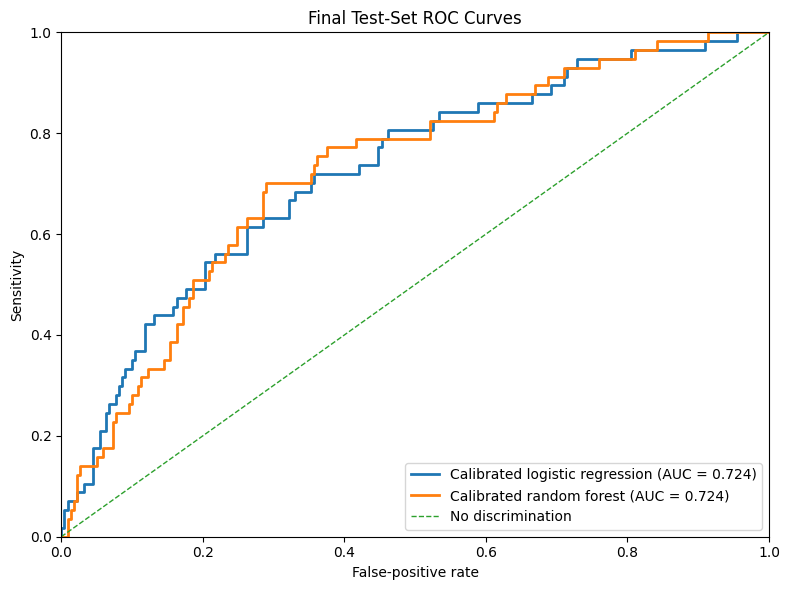

In [176]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

for model_name, probabilities in {
    "Calibrated logistic regression":
        primary_test_probability,

    "Calibrated random forest":
        secondary_test_probability,
}.items():

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            Y_TEST,
            probabilities,
        )
    )

    test_auc = roc_auc_score(
        Y_TEST,
        probabilities,
    )

    ax.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {test_auc:.3f})"
        ),
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="No discrimination",
)

ax.set_xlabel("False-positive rate")
ax.set_ylabel("Sensitivity")
ax.set_title("Final Test-Set ROC Curves")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="lower right")

fig.tight_layout()


FINAL_ROC_FIGURE = (
    MODELING_FIGURE_DIR
    / "final_test_roc_curves.png"
)

fig.savefig(
    FINAL_ROC_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Final precision-recall curve

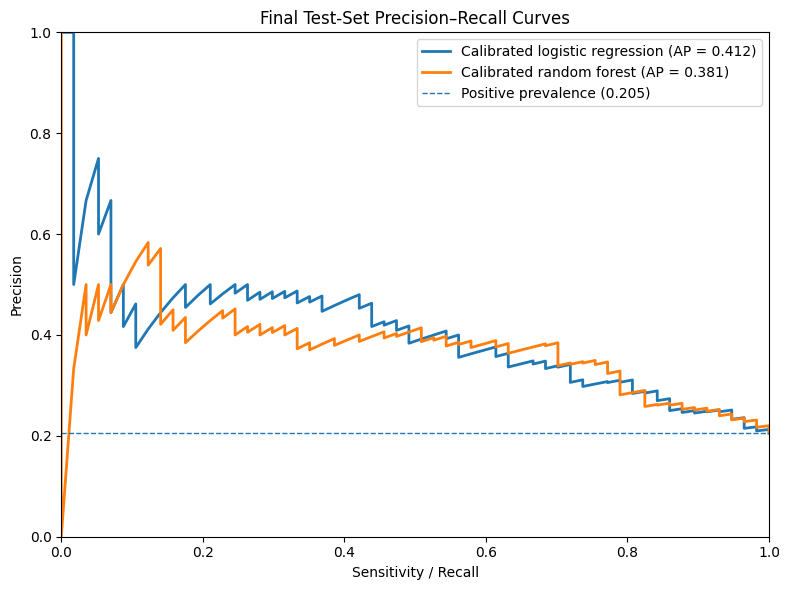

In [177]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

for model_name, probabilities in {
    "Calibrated logistic regression":
        primary_test_probability,

    "Calibrated random forest":
        secondary_test_probability,
}.items():

    precision_values, recall_values, _ = (
        precision_recall_curve(
            Y_TEST,
            probabilities,
        )
    )

    test_average_precision = (
        average_precision_score(
            Y_TEST,
            probabilities,
        )
    )

    ax.plot(
        recall_values,
        precision_values,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AP = {test_average_precision:.3f})"
        ),
    )


ax.axhline(
    Y_TEST.mean(),
    linestyle="--",
    linewidth=1,
    label=(
        "Positive prevalence "
        f"({Y_TEST.mean():.3f})"
    ),
)

ax.set_xlabel("Sensitivity / Recall")
ax.set_ylabel("Precision")
ax.set_title(
    "Final Test-Set Precision–Recall Curves"
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="best")

fig.tight_layout()


FINAL_PR_FIGURE = (
    MODELING_FIGURE_DIR
    / "final_test_precision_recall_curves.png"
)

fig.savefig(
    FINAL_PR_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Final calibration curve

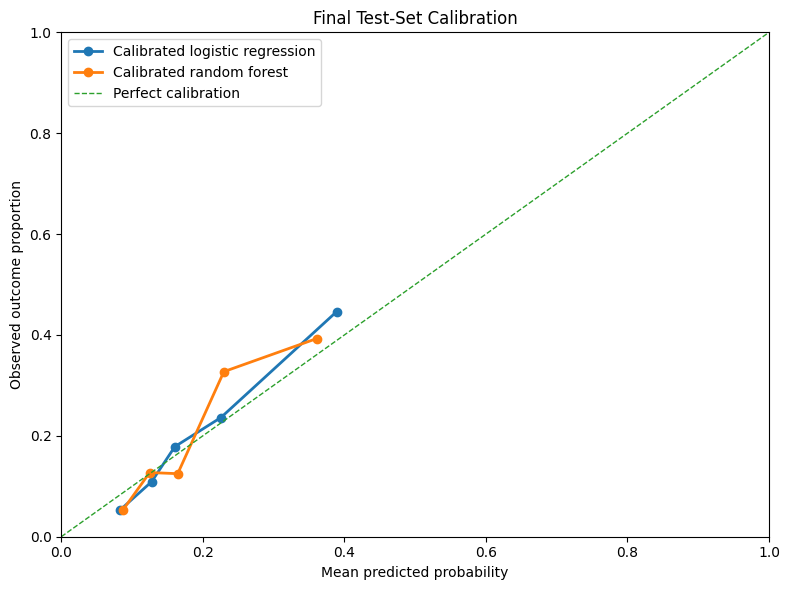

In [178]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

for model_name, probabilities in {
    "Calibrated logistic regression":
        primary_test_probability,

    "Calibrated random forest":
        secondary_test_probability,
}.items():

    observed_fraction, predicted_mean = (
        calibration_curve(
            Y_TEST,
            probabilities,
            n_bins=5,
            strategy="quantile",
        )
    )

    ax.plot(
        predicted_mean,
        observed_fraction,
        marker="o",
        linewidth=2,
        label=model_name,
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfect calibration",
)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed outcome proportion")
ax.set_title("Final Test-Set Calibration")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="best")

fig.tight_layout()


FINAL_CALIBRATION_FIGURE = (
    MODELING_FIGURE_DIR
    / "final_test_calibration.png"
)

fig.savefig(
    FINAL_CALIBRATION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Primary-model confusion matrix

In [179]:
primary_test_prediction = (
    primary_test_probability
    >= FINAL_PRIMARY_THRESHOLD
).astype("int8")


primary_confusion_matrix = confusion_matrix(
    Y_TEST,
    primary_test_prediction,
    labels=[0, 1],
)

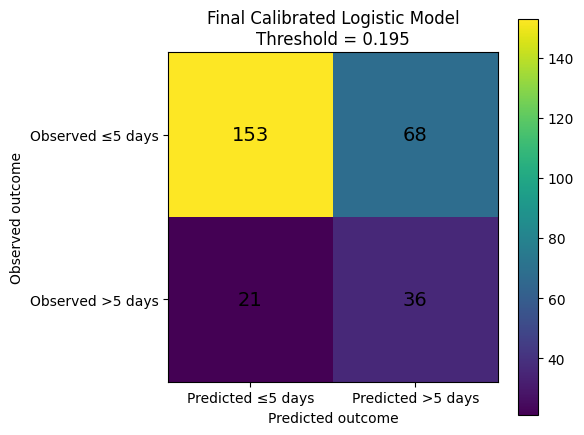

In [180]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    primary_confusion_matrix
)

for row in range(2):
    for column in range(2):
        ax.text(
            column,
            row,
            str(
                primary_confusion_matrix[
                    row,
                    column,
                ]
            ),
            ha="center",
            va="center",
            fontsize=14,
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    [
        "Predicted ≤5 days",
        "Predicted >5 days",
    ]
)

ax.set_yticklabels(
    [
        "Observed ≤5 days",
        "Observed >5 days",
    ]
)

ax.set_xlabel("Predicted outcome")
ax.set_ylabel("Observed outcome")

ax.set_title(
    "Final Calibrated Logistic Model\n"
    f"Threshold = {FINAL_PRIMARY_THRESHOLD:.3f}"
)

fig.colorbar(
    image,
    ax=ax,
)

fig.tight_layout()


CONFUSION_MATRIX_FIGURE = (
    MODELING_FIGURE_DIR
    / "final_primary_confusion_matrix.png"
)

fig.savefig(
    CONFUSION_MATRIX_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Creating the coefficient table

In [181]:
from sklearn.base import clone
from sklearn.inspection import permutation_importance

In [182]:
interpretability_logistic_model = clone(
    best_logistic_pipeline
)

interpretability_logistic_model.fit(
    X_DEVELOPMENT_B,
    Y_DEVELOPMENT,
)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,1.0
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Extracting the fitted components

In [183]:
fitted_preprocessor = (
    interpretability_logistic_model[
        "preprocessing"
    ]
)

fitted_classifier = (
    interpretability_logistic_model[
        "classifier"
    ]
)

#### Getting transformed feature names

In [184]:
transformed_feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

logistic_coefficients = (
    fitted_classifier.coef_[0]
)

assert (
    len(transformed_feature_names)
    == len(logistic_coefficients)
)

#### Creating a cleaning function

In [185]:
def clean_transformed_feature_name(
    feature_name: str,
) -> str:
    cleaned_name = (
        feature_name
        .replace(
            "numeric__",
            "",
        )
        .replace(
            "categorical__",
            "",
        )
        .replace(
            "missingindicator_",
            "missing__",
        )
    )

    return cleaned_name

In [186]:
coefficient_table = pd.DataFrame(
    {
        "transformed_feature": (
            transformed_feature_names
        ),
        "feature": [
            clean_transformed_feature_name(
                feature
            )
            for feature
            in transformed_feature_names
        ],
        "coefficient": (
            logistic_coefficients
        ),
    }
)

#### Adding direction and magnitude

In [187]:
coefficient_table[
    "absolute_coefficient"
] = coefficient_table[
    "coefficient"
].abs()


coefficient_table["direction"] = np.select(
    [
        coefficient_table[
            "coefficient"
        ].gt(0),

        coefficient_table[
            "coefficient"
        ].lt(0),
    ],
    [
        "Higher predicted risk",
        "Lower predicted risk",
    ],
    default="Coefficient removed by L1 penalty",
)


coefficient_table["nonzero"] = (
    coefficient_table[
        "coefficient"
    ]
    .ne(0)
)

#### Identifying the source block

In [188]:
def classify_interpretability_source(
    feature: str,
) -> str:
    feature_lower = feature.lower()

    if feature_lower.startswith("apv_"):
        return "APACHE prediction variables"

    if feature_lower.startswith("aps_"):
        return "APACHE physiology"

    if feature_lower.startswith("apr_"):
        return "APACHE severity"

    if feature_lower.startswith("lab_"):
        return "Laboratory"

    if feature_lower.startswith("vital_"):
        return "Vital signs"

    if feature_lower.startswith("history_"):
        return "Past history"

    return "Demographic or admission"

In [189]:
coefficient_table["source_block"] = (
    coefficient_table["feature"]
    .map(
        classify_interpretability_source
    )
)

#### Sorting and saving it

In [190]:
coefficient_table = (
    coefficient_table
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [191]:
COEFFICIENT_TABLE_FILE = (
    METRIC_DIR
    / "final_logistic_coefficient_table.csv"
)

coefficient_table.to_csv(
    COEFFICIENT_TABLE_FILE,
    index=False,
)

#### Checking the degree of sparsity produced by L1 regularization

In [192]:
coefficient_sparsity_summary = pd.DataFrame(
    {
        "measure": [
            "Transformed features",
            "Non-zero coefficients",
            "Zero coefficients",
            "Percentage removed by L1",
        ],
        "value": [
            len(coefficient_table),

            int(
                coefficient_table[
                    "nonzero"
                ].sum()
            ),

            int(
                (~coefficient_table[
                    "nonzero"
                ]).sum()
            ),

            (
                100
                * (
                    ~coefficient_table[
                        "nonzero"
                    ]
                ).mean()
            ),
        ],
    }
)

display(coefficient_sparsity_summary)

,measure,value
0,Transformed features,2122.000000
1,Non-zero coefficients,76.000000
2,Zero coefficients,2046.000000
3,Percentage removed by L1,96.418473


### Creating the coefficient figure

In [193]:
NUMBER_PER_DIRECTION = 10

In [194]:
nonzero_coefficients = (
    coefficient_table.loc[
        coefficient_table[
            "nonzero"
        ]
    ]
    .copy()
)


largest_positive_coefficients = (
    nonzero_coefficients
    .nlargest(
        NUMBER_PER_DIRECTION,
        "coefficient",
    )
)


largest_negative_coefficients = (
    nonzero_coefficients
    .nsmallest(
        NUMBER_PER_DIRECTION,
        "coefficient",
    )
)


coefficient_plot_data = pd.concat(
    [
        largest_negative_coefficients,
        largest_positive_coefficients,
    ],
    ignore_index=True,
)

In [195]:
coefficient_plot_data = (
    coefficient_plot_data
    .sort_values(
        "coefficient",
        ascending=True,
    )
)

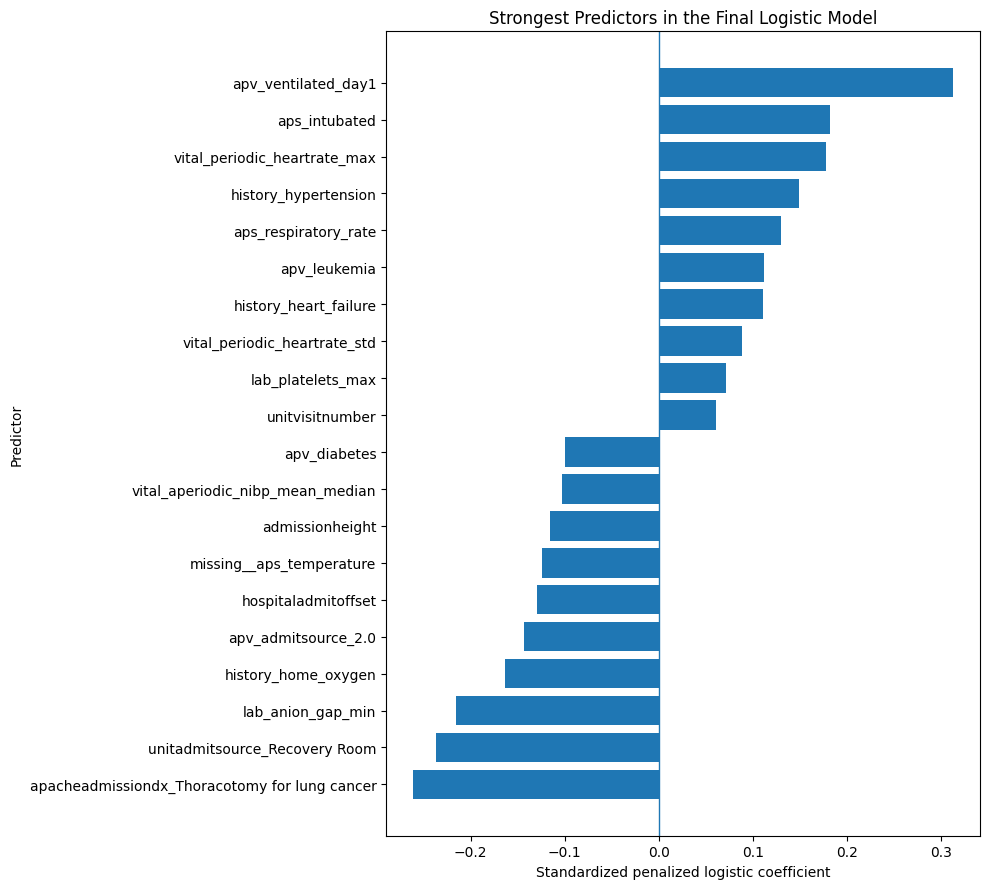

In [196]:
fig, ax = plt.subplots(
    figsize=(10, 9)
)

ax.barh(
    coefficient_plot_data[
        "feature"
    ],
    coefficient_plot_data[
        "coefficient"
    ],
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_xlabel(
    "Standardized penalized logistic coefficient"
)

ax.set_ylabel(
    "Predictor"
)

ax.set_title(
    "Strongest Predictors in the Final Logistic Model"
)

fig.tight_layout()


COEFFICIENT_FIGURE_FILE = (
    MODELING_FIGURE_DIR
    / "final_logistic_coefficients.png"
)

fig.savefig(
    COEFFICIENT_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Calculating test-set permutation importance

In [197]:
primary_permutation_importance = (
    permutation_importance(
        estimator=final_primary_model,
        X=X_TEST_B,
        y=Y_TEST,
        scoring="average_precision",
        n_repeats=30,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

#### Creating the table

In [198]:
permutation_importance_table = pd.DataFrame(
    {
        "feature": (
            X_TEST_B.columns
        ),

        "importance_mean": (
            primary_permutation_importance[
                "importances_mean"
            ]
        ),

        "importance_std": (
            primary_permutation_importance[
                "importances_std"
            ]
        ),
    }
)

In [199]:
permutation_importance_table[
    "source_block"
] = (
    permutation_importance_table[
        "feature"
    ]
    .map(
        classify_interpretability_source
    )
)


permutation_importance_table = (
    permutation_importance_table
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

#### Saving it

In [200]:
PERMUTATION_IMPORTANCE_FILE = (
    METRIC_DIR
    / "final_primary_permutation_importance.csv"
)

permutation_importance_table.to_csv(
    PERMUTATION_IMPORTANCE_FILE,
    index=False,
)

### Creating the permutation-importance figure

In [201]:
TOP_IMPORTANCE_FEATURES = 15

In [202]:
permutation_plot_data = (
    permutation_importance_table
    .head(
        TOP_IMPORTANCE_FEATURES
    )
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

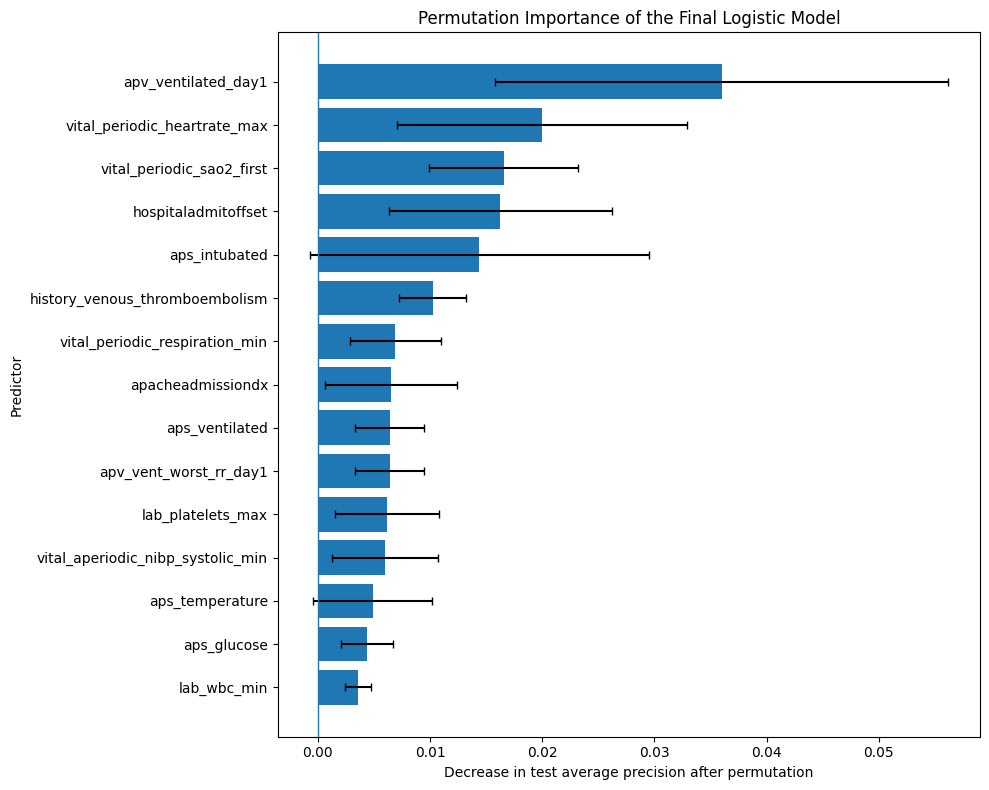

In [203]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.barh(
    permutation_plot_data[
        "feature"
    ],
    permutation_plot_data[
        "importance_mean"
    ],
    xerr=permutation_plot_data[
        "importance_std"
    ],
    capsize=3,
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_xlabel(
    "Decrease in test average precision after permutation"
)

ax.set_ylabel(
    "Predictor"
)

ax.set_title(
    "Permutation Importance of the Final Logistic Model"
)

fig.tight_layout()


PERMUTATION_FIGURE_FILE = (
    MODELING_FIGURE_DIR
    / "final_primary_permutation_importance.png"
)

fig.savefig(
    PERMUTATION_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Creating the report-ready performance table

In [204]:
PRIMARY_MODEL_NAME = (
    "Sigmoid-calibrated L1 logistic regression"
)

In [205]:
primary_metric_row = (
    final_test_metrics.loc[
        final_test_metrics[
            "model"
        ].eq(
            PRIMARY_MODEL_NAME
        )
    ]
    .iloc[0]
)

In [206]:
primary_ci_table = (
    final_bootstrap_ci.loc[
        final_bootstrap_ci[
            "model"
        ].eq(
            PRIMARY_MODEL_NAME
        )
    ]
    .set_index("metric")
)

In [207]:
REPORT_METRICS = {
    "roc_auc": "ROC-AUC",
    "average_precision": "Average precision",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "precision": "Precision",
    "negative_predictive_value": "Negative predictive value",
    "f1": "F1 score",
    "balanced_accuracy": "Balanced accuracy",
    "brier_score": "Brier score",
}

In [208]:
report_performance_rows = []


for metric, display_name in (
    REPORT_METRICS.items()
):
    estimate = float(
        primary_metric_row[metric]
    )

    ci_lower = float(
        primary_ci_table.loc[
            metric,
            "ci_lower_95",
        ]
    )

    ci_upper = float(
        primary_ci_table.loc[
            metric,
            "ci_upper_95",
        ]
    )

    report_performance_rows.append(
        {
            "metric": display_name,
            "estimate": estimate,
            "ci_lower_95": ci_lower,
            "ci_upper_95": ci_upper,
            "formatted_result": (
                f"{estimate:.3f} "
                f"({ci_lower:.3f}–"
                f"{ci_upper:.3f})"
            ),
        }
    )


report_performance_table = pd.DataFrame(
    report_performance_rows
)

In [209]:
display(
    report_performance_table[
        [
            "metric",
            "formatted_result",
        ]
    ]
)

,metric,formatted_result
0,ROC-AUC,0.724 (0.649–0.798)
1,Average precision,0.412 (0.306–0.549)
2,Sensitivity,0.632 (0.500–0.762)
3,Specificity,0.692 (0.633–0.748)
4,Precision,0.346 (0.255–0.435)
5,Negative predictive value,0.879 (0.829–0.927)
6,F1 score,0.447 (0.346–0.538)
7,Balanced accuracy,0.662 (0.594–0.731)
8,Brier score,0.146 (0.119–0.172)


In [210]:
REPORT_PERFORMANCE_FILE = (
    METRIC_DIR
    / "final_primary_report_performance_table.csv"
)

report_performance_table.to_csv(
    REPORT_PERFORMANCE_FILE,
    index=False,
)

### Saving the final analytical conclusion

In [211]:
final_analysis_summary = {
    "cohort": {
        "landmark_patients": 1389,
        "development_patients": 1111,
        "test_patients": 278,
        "test_positive_patients": 57,
        "test_positive_prevalence": (
            float(Y_TEST.mean())
        ),
    },

    "primary_model": {
        "name": (
            FINAL_PRIMARY_MODEL_NAME
        ),
        "threshold": (
            FINAL_PRIMARY_THRESHOLD
        ),
        "roc_auc": float(
            primary_metric_row[
                "roc_auc"
            ]
        ),
        "average_precision": float(
            primary_metric_row[
                "average_precision"
            ]
        ),
        "brier_score": float(
            primary_metric_row[
                "brier_score"
            ]
        ),
        "sensitivity": float(
            primary_metric_row[
                "sensitivity"
            ]
        ),
        "specificity": float(
            primary_metric_row[
                "specificity"
            ]
        ),
        "precision": float(
            primary_metric_row[
                "precision"
            ]
        ),
        "negative_predictive_value": float(
            primary_metric_row[
                "negative_predictive_value"
            ]
        ),
    },

    "interpretation": (
        "The final calibrated logistic model showed "
        "moderate discrimination and good overall "
        "probability calibration for early prediction "
        "of ICU stay longer than five days. Performance "
        "supports risk stratification research but is "
        "not sufficient for clinical deployment without "
        "external and prospective validation."
    ),
}

In [212]:
FINAL_ANALYSIS_SUMMARY_FILE = (
    METRIC_DIR
    / "final_analysis_summary.json"
)

with FINAL_ANALYSIS_SUMMARY_FILE.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_analysis_summary,
        file,
        indent=2,
    )

### Patient demographic details

In [2]:
import numpy as np
import pandas as pd

from config.paths import REDUCED_DATA_DIR, OUTPUT_DIR


INPUT_FILE = (
    REDUCED_DATA_DIR
    / "modeling_cohort_v001.csv"
)

OUTPUT_FILE = (
    OUTPUT_DIR
    / "metrics"
    / "demographic_dashboard_summary.csv"
)


df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
)

TARGET = "prolonged_icu_los"
AGE_COLUMN = "age"
SEX_COLUMN = "gender"


# -------------------------
# Clean age
# -------------------------
age_clean = (
    df[AGE_COLUMN]
    .astype("string")
    .str.strip()
    .replace(
        {
            "> 89": "90",
            ">89": "90",
        }
    )
)

df["age_numeric"] = pd.to_numeric(
    age_clean,
    errors="coerce",
)


# -------------------------
# Create age groups
# -------------------------
df["age_group"] = pd.cut(
    df["age_numeric"],
    bins=[
        -np.inf,
        49,
        59,
        69,
        79,
        89,
        np.inf,
    ],
    labels=[
        "<50",
        "50–59",
        "60–69",
        "70–79",
        "80–89",
        ">89 / anonymized",
    ],
)


# -------------------------
# Clean sex
# -------------------------
df["sex_clean"] = (
    df[SEX_COLUMN]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .replace(
        {
            "": "Unknown",
            "nan": "Unknown",
        }
    )
)


# -------------------------
# Age-group summary
# -------------------------
age_summary = (
    df.groupby(
        "age_group",
        observed=False,
        dropna=False,
    )
    .agg(
        patient_count=(
            TARGET,
            "size",
        ),
        prolonged_count=(
            TARGET,
            "sum",
        ),
    )
    .reset_index()
    .rename(
        columns={
            "age_group": "category",
        }
    )
)

age_summary["summary_type"] = "age_group"

age_summary["prolonged_percent"] = (
    100
    * age_summary["prolonged_count"]
    / age_summary["patient_count"]
)


# -------------------------
# Sex summary
# -------------------------
sex_summary = (
    df.groupby(
        "sex_clean",
        dropna=False,
    )
    .agg(
        patient_count=(
            TARGET,
            "size",
        ),
        prolonged_count=(
            TARGET,
            "sum",
        ),
    )
    .reset_index()
    .rename(
        columns={
            "sex_clean": "category",
        }
    )
)

sex_summary["summary_type"] = "sex"

sex_summary["prolonged_percent"] = (
    100
    * sex_summary["prolonged_count"]
    / sex_summary["patient_count"]
)


# -------------------------
# Overall age statistics
# -------------------------
age_statistics = pd.DataFrame(
    {
        "summary_type": [
            "age_statistic",
            "age_statistic",
            "age_statistic",
            "age_statistic",
        ],
        "category": [
            "Median age",
            "Age Q1",
            "Age Q3",
            "Age missing",
        ],
        "patient_count": [
            df["age_numeric"].median(),
            df["age_numeric"].quantile(0.25),
            df["age_numeric"].quantile(0.75),
            df["age_numeric"].isna().sum(),
        ],
        "prolonged_count": np.nan,
        "prolonged_percent": np.nan,
    }
)


# -------------------------
# Combine and export
# -------------------------
demographic_summary = pd.concat(
    [
        age_summary,
        sex_summary,
        age_statistics,
    ],
    ignore_index=True,
)


demographic_summary = demographic_summary[
    [
        "summary_type",
        "category",
        "patient_count",
        "prolonged_count",
        "prolonged_percent",
    ]
]


OUTPUT_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

demographic_summary.to_csv(
    OUTPUT_FILE,
    index=False,
)


print(demographic_summary)
print(f"\nSaved to: {OUTPUT_FILE}")

     summary_type          category  patient_count  prolonged_count  \
0       age_group               <50           66.0             10.0   
1       age_group             50–59          265.0             54.0   
2       age_group             60–69          426.0             88.0   
3       age_group             70–79          458.0             96.0   
4       age_group             80–89          164.0             36.0   
5       age_group  >89 / anonymized           10.0              2.0   
6             sex            Female          661.0            131.0   
7             sex              Male          728.0            155.0   
8   age_statistic        Median age           68.0              NaN   
9   age_statistic            Age Q1           60.0              NaN   
10  age_statistic            Age Q3           75.0              NaN   
11  age_statistic       Age missing            0.0              NaN   

    prolonged_percent  
0           15.151515  
1           20.377358  
2   

In [6]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# -----------------------------
# File path
# -----------------------------
INPUT_FILE = (
    OUTPUT_DIR
    / "metrics"
    / "development_calibration_comparison.csv")
OUTPUT_HTML = (
    OUTPUT_DIR
    / "figures"
    / "final_storytelling/11_model_comparison_after_tuning_and_calibration.html")
OUTPUT_PNG = (
    OUTPUT_DIR
    / "figures"
    / "final_storytelling/11_model_comparison_after_tuning_and_calibration.png")
OUTPUT_SVG = (
    OUTPUT_DIR
    / "figures"
    / "final_storytelling/11_model_comparison_after_tuning_and_calibration.svg")

OUTPUT_HTML.parent.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(INPUT_FILE)

# Keep only the needed columns
plot_df = df[
    [
        "model",
        "calibration_status",
        "average_precision",
        "roc_auc",
        "brier_score",
    ]
].copy()

# Create a prettier label
plot_df["display_model"] = (
    plot_df["model"]
    + " — "
    + plot_df["calibration_status"]
)

# Reshape for faceted plotting
long_df = plot_df.melt(
    id_vars=["display_model"],
    value_vars=["average_precision", "roc_auc", "brier_score"],
    var_name="metric",
    value_name="value",
)

# Friendly metric names
metric_labels = {
    "average_precision": "Average Precision",
    "roc_auc": "ROC-AUC",
    "brier_score": "Brier Score",
}

long_df["metric"] = long_df["metric"].map(metric_labels)

# Order of models
model_order = [
    "Elastic-net logistic regression — Uncalibrated",
    "Elastic-net logistic regression — Sigmoid calibrated",
    "Random forest — Uncalibrated",
    "Random forest — Sigmoid calibrated",
]

long_df["display_model"] = pd.Categorical(
    long_df["display_model"],
    categories=model_order,
    ordered=True,
)

# -----------------------------
# Plot
# -----------------------------
fig = px.bar(
    long_df,
    x="display_model",
    y="value",
    color="display_model",
    facet_col="metric",
    category_orders={"display_model": model_order},
    text="value",
    title="Model Comparison After Tuning and Calibration",
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
)

fig.update_layout(
    template="plotly_white",
    showlegend=False,
    height=550,
    width=1800,
    title_x=0.5,
    font=dict(size=14),
    margin=dict(t=80, l=40, r=40, b=120),
)

fig.update_xaxes(
    title_text="",
    tickangle=-25,
)

fig.update_yaxes(title_text="Metric value")

# Improve facet titles
fig.for_each_annotation(
    lambda a: a.update(text=a.text.split("=")[-1])
)

# Optional: different y-axis ranges per panel
# (kept automatic for simplicity)

# -----------------------------
# Save
# -----------------------------
fig.write_html(OUTPUT_HTML)
fig.write_image(OUTPUT_PNG, scale=2)
fig.write_image(OUTPUT_SVG)

fig.show()

In [21]:
import importlib
import final_visuals

importlib.reload(final_visuals)

print(final_visuals.__file__)

D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\final_visuals.py


In [22]:
generated_files = (
    final_visuals
    .create_before_after_model_comparison_figures(
        baseline_summary_csv=(
            METRICS_DIR
            / "baseline_cross_validation_summary.csv"
        ),
        calibration_comparison_csv=(
            METRICS_DIR
            / "development_calibration_comparison.csv"
        ),
        output_directory=FINAL_FIGURES_DIR,
    )
)

Resorting to unclean kill browser.
Resorting to unclean kill browser.
Resorting to unclean kill browser.
Resorting to unclean kill browser.


In [23]:
from datetime import datetime

for name, path in generated_files.items():
    modified = datetime.fromtimestamp(
        path.stat().st_mtime
    )

    print(
        name,
        path,
        modified,
        sep="\n",
    )

before_png
D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\figures\final_storytelling\04a_before_tuning_model_comparison.png
2026-07-23 01:20:33.162016
before_svg
D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\figures\final_storytelling\04a_before_tuning_model_comparison.svg
2026-07-23 01:20:48.568022
before_html
D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\figures\final_storytelling\04a_before_tuning_model_comparison.html
2026-07-23 01:20:48.634494
after_png
D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\figures\final_storytelling\04b_after_tuning_and_calibration.png
2026-07-23 01:21:07.448518
after_svg
D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-lo